<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Supervivencia en Cáncer de Mama y Pulmón</p>
<p style="margin: 0; text-align:right;">2026-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
<p style="margin: 0; text-align:right;">Julio Úbeda Quesada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# Análisis de Supervivencia y Predicción de Riesgo Clínico: Estudio Comparativo en Cáncer de Mama y Pulmón

El objetivo generarl del presente *jupyter notebook*  es realizar un estudio comparativo de rendimiento entre modelos estadísticos clásicos, modelos de Machine Learning y arquitecturas de Deep Learning para la predicción de riesgo y supervivencia en pacientes oncológicos. El foco principal es determinar si la complejidad de los modelos modernos (RSF, DeepSurv) ofrece una mejora significativa frente a los estándares clínicos (Cox, Kaplan-Meier).

Para la correcta ejecución del cuaderno necesitaremos importar los siguientes módulos:

In [1]:
# Sistema
import os
import sys
import warnings

# Ciencia de datos
import numpy as np
import pandas as pd
import re

# Estadística
from scipy import stats
from scipy.stats import wilcoxon
from scipy.stats.mstats import winsorize

# Visualización
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Supervivencia — lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# Supervivencia — scikit-survival
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    concordance_index_ipcw,
    brier_score,
    integrated_brier_score
)
from sksurv.util import Surv

# Deep Learning — PyTorch / pycox
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import CoxPH as DeepSurvModel

# ── Configuración del entorno ────────────────────────────────────────────────

warnings.filterwarnings('ignore')

# Ruta raíz (útil en notebooks)
root_dir = os.path.abspath('..')
sys.path.append(root_dir)

# Configuración de pandas
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Info entorno
print("✓ Imports completados.")
print(f"  PyTorch  : {torch.__version__}")
print(f"  CUDA     : {'disponible' if torch.cuda.is_available() else 'no disponible — CPU'}")

✓ Imports completados.
  PyTorch  : 2.10.0+cpu
  CUDA     : no disponible — CPU


In [2]:
# Importa y actualiza las funciones personalizadas desde utils.
import importlib
import utils.EDA_functions as eda
import utils.KMmodel_functions as KM
importlib.reload(eda)
importlib.reload(KM)

<module 'utils.KMmodel_functions' from 'c:\\Users\\usuario\\Documents\\GitHub\\TFM---Analisis-de-supervivencia-del-cancer\\Modulo 3 - Diseño e implementacion del trabajo\\utils\\KMmodel_functions.py'>

---

# 1. Estrategia de Adquisición de datos de cáncer de mama y de pulmón

Para evitar lidiar con la complejidad de la API de GDC o las dependencias de R (`TCGAbiolinks`), se extrajeron los datos directamente desde el *Datahub* público de [cBioPortal Datasets](https://www.cbioportal.org/datasets). 

Los identificadores de los conjunstos de datos son:

* **METABRIC (Cáncer de mama):** `brca_metabric_clinical_data`. 
* **TCGA-BRCA (Cáncer de mama):** `brca_tcga_gdc_clinical_data`.
* **TCGA-LUAD (Adenocarcinoma de pulmón) & TCGA-LUSC (Carcinoma escamoso de pulmón):** `nsclc_ctdx_msk_2022_clinical_data`

---

# 2. Cargar los datos clínicos

En este apartado se realiza la carga de los datasets clínicos previamente descargados. Para ello, se emplea un enfoque automatizado que permite leer múltiples archivos en formato `.tsv` y almacenarlos en una estructura de tipo diccionario, donde cada clave corresponde al nombre del dataset y su valor asociado es un *DataFrame* de `pandas`. 

In [6]:
# Definir la lista con las rutas de tus 3 archivos .tsv
rutas_archivos = [
    r"../data/brca_metabric_clinical_data.tsv",
    r"../data/brca_tcga_gdc_clinical_data.tsv",
    r"../data/nsclc_ctdx_msk_2022_clinical_data.tsv"  
]

# Crea el diccionario vacío para almacenar los DataFrames
diccionario_datos = {}

# Bucle para importar y guardar cada archivo
for ruta in rutas_archivos:
    # Extraer el nombre base del archivo y quitarle la extensión '.tsv'
    nombre_clave = os.path.basename(ruta).replace('.tsv', '')
    
    # Leer el .tsv y asignarlo al diccionario
    diccionario_datos[nombre_clave] = pd.read_csv(ruta, sep='\t')

diccionario_datos.keys()  # Mostrar las claves para verificar que se han importado correctamente

dict_keys(['brca_metabric_clinical_data', 'brca_tcga_gdc_clinical_data', 'nsclc_ctdx_msk_2022_clinical_data'])

---

# **3. Breast Cancer (METABRIC, Nature 2012 & Nat Commun 2016)**

El **METABRIC** (*Molecular Taxonomy of Breast Cancer International Consortium*) es uno de los repositorios más robustos y citados en la investigación oncológica. Este conjunto de datos transformó la comprensión del cáncer de mama al integrar perfiles genómicos y transcriptómicos con datos clínicos de seguimiento a muy largo plazo (más de 20 años).

Es el estándar de oro para el **descubrimiento de subtipos moleculares**, el estudio de la heterogeneidad tumoral y el entrenamiento de modelos predictivos de **supervivencia**. Su relevancia radica en la escala de la cohorte y la profundidad de su caracterización multiómica, lo que permite correlacionar alteraciones genéticas específicas con el pronóstico real de las pacientes.

Información complementaria:
* **Enlace de descarga:** [cBioPortal - METABRIC](https://www.cbioportal.org/study/summary?id=brca_metabric)
* **Papers relacionados:** Pereira et al. Nat Commun 2016, Rueda et al. Nature 2019, Curtis et al. Nature 2012.

## **3.1. Descripción  del conjunto de datos**

### **A. Dimensiones y tipo de datos**

El conjunto de datos de la cohorte METABRIC revela la siguiente composición:

* **Dimensiones globales:** El dataset consta de **2.509 registros (filas)** y **39 variables (columnas)**. 
  
* **Tipología de datos:**
    * **Variables numéricas (`float64`, `int64`):** Representan mediciones temporales continuas, parámetros físicos o recuentos absolutos (ej. `Age at Diagnosis`, `Tumor Size`, `Mutation Count`, `Overall Survival (Months)`).
    * **Variables categóricas y de texto (`str`, `object`):** Conforman la mayoría del dataset y recogen clasificaciones clínicas estandarizadas, estados patológicos, identificadores y variables binarias (ej. `Cancer Type Detailed`, `ER Status`, `Overall Survival Status`).

### **B. Valores nulos**

A continuación, se detalla la integridad de los datos organizada por niveles de ausencia:

* **Completitud Total (0% - 1% nulos):** Los identificadores, el tipo de cáncer, el sexo y la carga mutacional (`TMB`) están presentes en la totalidad de los registros. La información sobre recaídas (`Relapse Free Status`) y edad también roza la integridad total.

* **Sesgo de Registro Clínico (3% - 11% nulos):** Las variables patológicas básicas como el estatus de estrógenos (`ER`), el grado histológico, el tamaño tumoral y el conteo de ganglios muestran una alta fiabilidad.

* **Bloque Crítico (~21% nulos):** Existe una falta de información que afecta simultáneamente al **21% de la cohorte**. Este bloque impacta en:
    * **Tratamientos:** Quimioterapia, Hormonoterapia y Radioterapia.
    * **Supervivencia:** El estatus vital y los meses de supervivencia global.
    * **Biomarcadores:** Estatus de HER2, PR y clasificaciones moleculares (Pam50).

* **Máxima Fragmentación (23% - 30% nulos):**
    Las variables de `Cellularity`, `Laterality`, `Tumor Stage` (28.7%) y el clasificador de 3 genes (29.7%) presentan la mayor carencia. 

In [7]:
# Acceder al DataFrame por su clave:
brca_metabric = diccionario_datos['brca_metabric_clinical_data']
eda.describe_df(brca_metabric)

Dimensiones del DataFrame: 2509 filas, 39 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,object,2509,0.00,1,brca_metabric (2509),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,object,2509,0.00,2509,"MB-0000 (1), MB-0002 (1), MB-0005 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,object,2509,0.00,2509,"MB-0000 (1), MB-0002 (1), MB-0005 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Age at Diagnosis,float64,2498,0.44,1843,None,60.420300,61.110000,13.032997,21.93,50.920000,70.000000,96.290000
4,Type of Breast Surgery,object,1955,22.08,2,"MASTECTOMY (1170), BREAST CONSERVING (785)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Cancer Type,object,2509,0.00,1,Breast Cancer (2509),NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type Detailed,object,2509,0.00,8,"Breast Invasive Ductal Carcinoma (1865), Breast Mixed Ductal and Lobular Carcinoma (269), Breast Invasive Lobular Carcinoma (192)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cellularity,object,1917,23.60,3,"High (965), Moderate (737), Low (215)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Chemotherapy,object,1980,21.08,2,"NO (1568), YES (412)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Pam50 + Claudin-low subtype,object,1980,21.08,7,"LumA (700), LumB (475), Her2 (224)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **3.2. Análisis estadístico básico**

En este apartado se realiza un análisis estadístico básico del conjunto de datos `brca_metabric_clinical_data`. El objetivo es explorar las principales características de las variables disponibles, distinguiendo entre variables categóricas y variables numéricas, y agrupándolas según sus familias lógicas (identificadores, metadatos, clinico-demográficos, anatómicas, entre otras).

### **3.2.1. Análisis de Variables Categóricas: Distribución y Tendencias**

A continuación, se analiza la distribución de las variables categóricas organizadas por familias lógicas:

#### **A. Identificadores y Metadatos del Estudio (Varianza Cero)**
  * **Identificadores Únicos (`Patient ID`, `Sample ID`):** Presentan una cardinalidad máxima (2.509 valores únicos), lo que confirma la ausencia de duplicados y una relación unívoca entre paciente y muestra.
  * **Variables de Varianza Cero (`Study ID`, `Cancer Type`, `Sample Type`, `Sex`):** Estas variables funcionan como constantes en METABRIC. El 100% de la muestra pertenece al estudio METABRIC, son tumores de mama (`Breast Cancer`), de tipo primario (`Primary`) y en pacientes femeninas (`Female`). 

In [34]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Patient ID', 'Sample ID', 'Study ID', 'Cancer Type', 'Sample Type', 'Sex', 'Breast Cancer'])],
    group_name="Identificadores y Metadatos del Estudio (Varianza Cero)",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Identificadores_y_Metadatos_del_Estudio_(Varianza_Cero).html


#### **B. Perfil Clínico-Demográfico y Anatómico**
  * **Celularidad (`Cellularity`):** La mayoría de las muestras presentan una celularidad **Alta** (965) o **Moderada** (737), con una minoría de casos bajos (215).
  * **Estado Menopáusico (`Inferred Menopausal State`):** Existe una clara tendencia hacia pacientes **postmenopáusicas** (1.556 casos), lo cual es coherente con la distribución de edad observada en las variables numéricas.
  * **Lateralidad (`Primary Tumor Laterality`):** La distribución es casi simétrica entre la mama izquierda (973) y derecha (897), indicando que el origen anatómico del tumor no presenta un sesgo lateral en esta cohorte.
 

In [14]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Inferred Menopausal State', 'Primary Tumor Laterality', 'Cellularity'])],
    group_name="Perfil Clínico-Demográfico y Anatómico",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Perfil_Clínico-Demográfico_y_Anatómico.html


#### **C. Caracterización Histológica y Patológica**
  * **Clasificación de la Enfermedad (`Cancer Type Detailed`, `Oncotree Code`, `Tumor Other Histologic Subtype`):** Se observa una **dominancia masiva del Carcinoma Ductal Invasivo (IDC)** (1.865 casos), que es el subtipo más común a nivel global. Los subtipos Mixto y Lobular aparecen en frecuencias mucho menores.

In [61]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Cancer Type Detailed', 'Oncotree Code', 'Tumor Other Histologic Subtype'])],
    group_name="Caracterización Histológica y Patológica",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Caracterización_Histológica_y_Patológica.html


#### **D. Biomarcadores Moleculares y Subtipos**
  * **Estado de Receptores (`ER Status`, `PR Status`, `HER2 Status`):** 
      * El perfil predominante es **ER Positivo** (1.825) y **PR Positivo** (1.040).
      * En contraste, el **HER2 Negativo** es la norma (1.733), validado consistentemente por los métodos IHC y SNP6.

  * **Clasificadores Intrínsecos (`Pam50 + Claudin-low`, `3-Gene classifier subtype`, `Integrative Cluster`):** 
      * En el gráfico de `Pam50`, los subtipos **Luminal A** (700) y **Luminal B** (475) son los más frecuentes, alineándose con la positividad de los receptores de estrógeno. 
      * La variable `Integrative Cluster` muestra una distribución más fragmentada en 10 grupos, capturando la heterogeneidad genómica de la enfermedad.

In [17]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['ER Status', 'PR Status', 'HER2 Status', 'Pam50 + Claudin-low subtype', '3-Gene classifier subtype', 'Integrative Cluster'])],
    group_name="Biomarcadores Moleculares y Subtipos",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Biomarcadores_Moleculares_y_Subtipos.html


#### **E. Intervenciones Terapéuticas**
  * **Tratamientos Adyuvantes (`Chemotherapy`, `Hormone Therapy`, `Radio Therapy`):**
      * Existe un fuerte desbalance en **Quimioterapia** (la gran mayoría no la recibió: 1.568 vs 412).
      * La **Terapia Hormonal** (1.216 Sí) y la **Radioterapia** (1.173 Sí) son mucho más comunes, reflejando el estándar de cuidado para tumores Luminales/ER+.
  * **Procedimiento Quirúrgico (`Type of Breast Surgery`):** La tendencia se inclina ligeramente hacia la **Mastectomía** (1.170) frente a la cirugía conservadora (785).

In [18]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Chemotherapy', 'Hormone Therapy', 'Radio Therapy', 'Type of Breast Surgery'])],
    group_name="Intervenciones Terapéuticas",
    dataset_name="METABRIC",
    ncol=2, 
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Intervenciones_Terapéuticas.html


#### **F. Variables Estado de Supervivencia (Variables Objetivo o `Target`):**
  * **Estado de Supervivencia (`Overall Survival Status`, `Patient's Vital Status`):** Se observa una distribución informativa de eventos (aproximadamente el 58% de los pacientes fallecieron (`Decreased`)), que proporciona suficientes datos para el análisis de riesgo.
  * **Estado de Recaída (`Relapse Free Status`):** La mayoría de las pacientes se mantuvieron libres de progresión (`0:Not Recurred`), aunque existe un volumen crítico de 1.002 eventos de recaída para el modelado.

In [19]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Overall Survival Status', "Patient's Vital Status", 'Relapse Free Status'])],
    group_name="Variables de Estado de Supervivencia",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Variables_de_Estado_de_Supervivencia.html


### **3.2.2. Análisis de Variables Numéricas: Distribución y Tendencias**

A continuación, se analiza la distribución de las variables numéricas organizadas por familias lógicas:

#### **A. Demografía y Contexto de la Cohorte**

  * **`Age at Diagnosis` (Distribución Gausiana):** Es la variable con el comportamiento más cercano a una distribución normal. Muestra una madurez demográfica clara con una **media de 60.4 años**. Visualmente, el pico de moda se sitúa entre los 60 y 70 años, confirmando que es una cohorte mayoritariamente postmenopáusica, aunque la base ancha del histograma captura casos desde la juventud (21 años) hasta la longevidad extrema (96 años).
  * **`Cohort` (Discreta Multimodal):** Aunque numérica, su gráfico muestra que los datos no son continuos, sino que se agrupan en bloques. La tendencia es descendente, la gran mayoría de los datos provienen de las primeras tres cohortes de recolección, disminuyendo drásticamente en las cohortes 4 a 9.

In [20]:
eda.plot_numerical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Age at Diagnosis', 'Cohort'])],
    group_name="Demografía y Contexto de la Cohorte",
    dataset_name="METABRIC",
    ncol = 2,
    output_path=r"..\images\EDA"
)

✔ Numerical subplots guardado en: ..\images\EDA\METABRIC_num_subplots_Demografía_y_Contexto_de_la_Cohorte.html


#### **B. Parámetros Clínico-Patológicos**
  * **`Tumor Size` (Sesgo Positivo):** Presenta una distribución asimétrica hacia la derecha. El grueso de los tumores se concentra entre los **10 y 30 mm**, pero existe una cola larga de casos con tamaños superiores a 100 mm. Esto indica que la mayoría de los tumores son `Tumor Stage` T1/T2, pero hay casos aislados de enfermedad muy avanzada.
  * **`Lymph nodes examined positive` (Sesgo Extremo):** Visualmente, el histograma es una "pared" en el valor 0. La tendencia central es de baja afectación ganglionar, pero los valores atípicos que llegan hasta 45 ganglios positivos representan fenotipos de alta agresividad y riesgo de metástasis.
  * **`Nottingham prognostic index` (Multimodal):** A diferencia de las otras, esta variable presenta varios picos. Refleja visualmente los tres grupos de pronóstico clínico (bueno, intermedio y pobre). El pico más alto está en torno a un índice de 4, lo que sugiere un riesgo intermedio-alto predominante en la cohorte.
  * `Tumor Stage` y `Neoplasm Histologic Grade`: Aunque codificados numéricamente, actúan como categorías ordinales. El **Estadio 2** y el **Grado 3** son las categorías modales, lo que indica una cohorte donde la enfermedad se suele detectar en fases intermedias pero con características celulares agresivas.

In [68]:
eda.plot_numerical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Tumor Size', 'Lymph nodes examined positive', 'Nottingham prognostic index', 'Tumor Stage', 'Neoplasm Histologic Grade'])],
    group_name="Parámetros Clínico-Patológicos",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Numerical subplots guardado en: ..\images\EDA\METABRIC_num_subplots_Parámetros_Clínico-Patológicos.html


#### **C. Métricas de Agresividad Molecular**
  * **`Mutation Count` y `TMB (nonsynonymous)`:** Ambas variables son prácticamente idénticas en forma (confirmando su correlación de 1.0). La tendencia es de **baja carga mutacional** (mediana de 5). El hecho de que la gran mayoría de los casos se amontone cerca del cero indica que el cáncer de mama primario es genómicamente "estable" en comparación con otros tejidos, aunque la presencia de outliers sugiere la existencia de un subgrupo hipermutador.

In [22]:
eda.plot_numerical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Mutation Count', 'TMB (nonsynonymous)'])],
    group_name="Métricas de Agresividad Molecular",
    dataset_name="METABRIC",
    ncol = 2,
    output_path=r"..\images\EDA"
)

✔ Numerical subplots guardado en: ..\images\EDA\METABRIC_num_subplots_Métricas_de_Agresividad_Molecular.html


#### **D. Variables Temporales de Supervivencia (Variables Objetivo o `Target`)**
  * **`Overall Survival (Months)` y `Relapse Free Status (Months)`:** Ambas muestran distribuciones muy similares con una base muy extensa. La frecuencia de supervivencia se mantiene relativamente alta y constante hasta los 150-200 meses, donde empieza a decaer. La cola llega hasta los **350 meses**, lo que visualmente demuestra un seguimiento clínico excepcional de casi 30 años.

In [23]:
eda.plot_numerical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Overall Survival (Months)', 'Relapse Free Status (Months)'])],
    group_name="Métricas de Supervivencia",
    dataset_name="METABRIC", ncol = 2,
    output_path=r"..\images\EDA"
)

✔ Numerical subplots guardado en: ..\images\EDA\METABRIC_num_subplots_Métricas_de_Supervivencia.html


#### **E. Variables de Estructura (Varianza Cero)**
  * **`Number of Samples Per Patient`:** El histograma muestra una única barra masiva en el valor 1. Esto confirma visualmente la granularidad del dataset, un registro por paciente, eliminando la necesidad de modelos de medidas repetidas.

In [24]:
eda.plot_numerical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Number of Samples Per Patient'])],
    group_name="Variables de Estructura (Varianza Cero)",
    dataset_name="METABRIC", ncol=1,
    output_path=r"..\images\EDA"
)

✔ Numerical subplots guardado en: ..\images\EDA\METABRIC_num_subplots_Variables_de_Estructura_(Varianza_Cero).html


### **3.2.3. Análisis de Correlaciones (Heatmap)**

A continuación, se analiza las correlaciones de las variables numéricas (excepto `Number of Samples Per Patient`):

#### **A. Relaciones de Dependencia y Redundancia (Alta Correlación)**
* **`TMB` vs `Mutation Count` (1.00):** Existe una correlación perfecta. Esto indica que ambas variables miden el mismo fenómeno biológico en este dataset. 
* **`Overall Survival` vs `Relapse Free Status` (0.90):** Una correlación positiva muy fuerte que valida la lógica clínica: los pacientes que tardan más en recaer son, sistemáticamente, los que presentan una mayor supervivencia global.
* **`Nottingham Prognostic Index` (NPI) y Gravedad:** El NPI muestra correlaciones sólidas con el `Neoplasm Histologic Grade` (**0.70**) y el `Tumor Stage` (**0.55**). Esto confirma visualmente que el NPI funciona como una métrica compuesta que integra la agresividad celular y la extensión del tumor.

#### **B. Relaciones Inversas con la Supervivencia (Impacto Pronóstico)**
* **Variables de Gravedad vs Supervivencia:** Se observa una tendencia de correlación negativa entre los meses de vida (`Overall Survival`) y factores como el `Tumor Stage` (**-0.27**), el `Nottingham prognostic index` (**-0.24**) y el `Tumor Size` (**-0.19**). Aunque los valores absolutos parecen moderados, confirman que a medida que aumentan estos índices de gravedad, el tiempo de supervivencia tiende a disminuir.

#### **C. Independencia de Variables (Baja Correlación)**
* **`Age at Diagnosis`:** Presenta una correlación cercana a cero con casi todas las métricas moleculares y patológicas (ej. **0.03** con `Mutation Count` o **0.06** con `Tumor Size`). Esto sugiere que la agresividad del tumor en METABRIC es independiente de la edad de la paciente al momento del diagnóstico.
* **`Cohort`:** No muestra relaciones significativas con las variables clínicas, lo que indica que el proceso de recolección de muestras no introdujo sesgos sistemáticos en variables críticas como el tamaño o el grado tumoral.

✔ Heatmap guardado en: ../images/EDA\METABRIC_heatmap_correlaciones.png


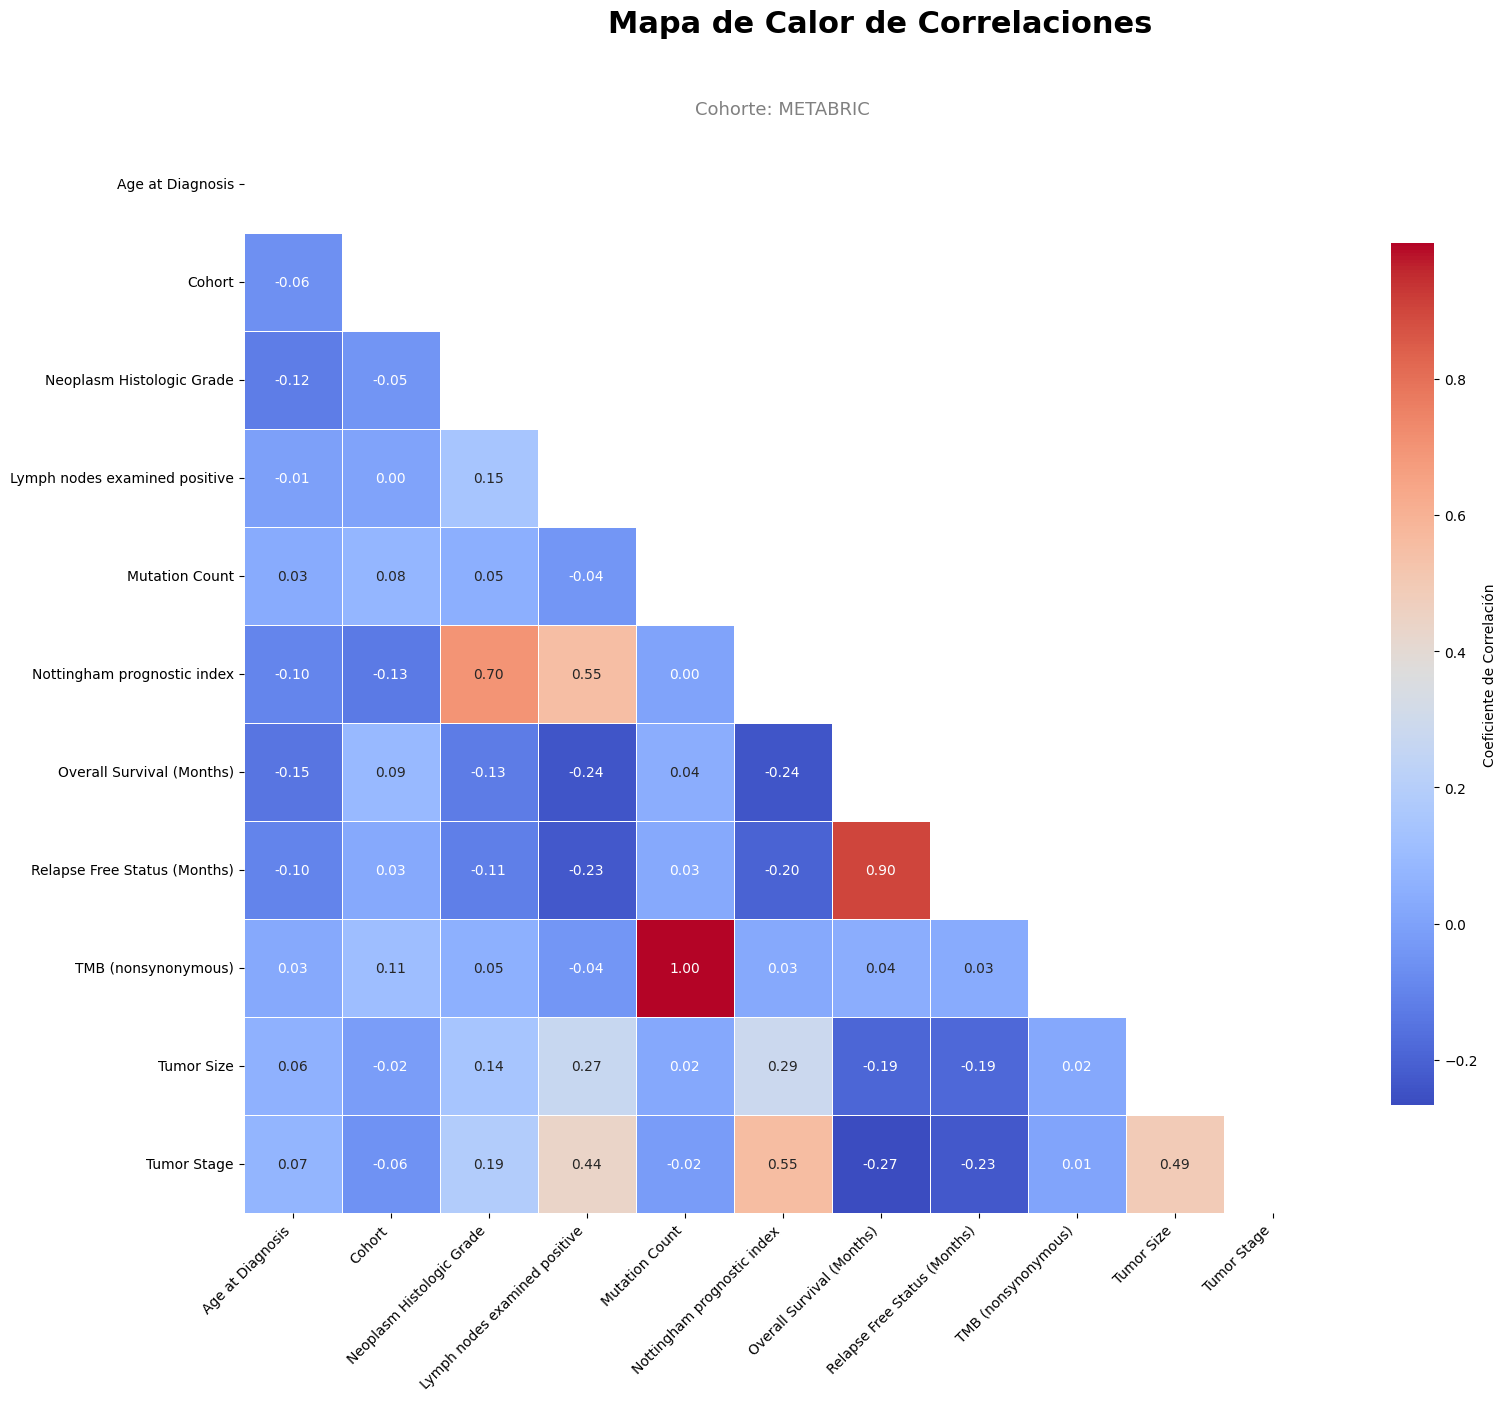


════════════════════════════════════════════════════════════════════════════════
  Resumen de Correlaciones — METABRIC (Pearson)
════════════════════════════════════════════════════════════════════════════════
  Etiqueta   Par de variables                                                  Corr
  ────────── ────────────────────────────────────────────────────────────── ───────
  ▲ Top 1    TMB (nonsynonymous)  ↔  Mutation Count                          0.9992
  ▲ Top 2    Relapse Free Status (Months)  ↔  Overall Survival (Months)      0.9023
  ▲ Top 3    Nottingham prognostic index  ↔  Neoplasm Histologic Grade       0.6997
  ▲ Top 4    Tumor Stage  ↔  Nottingham prognostic index                     0.5543
  ▲ Top 5    Nottingham prognostic index  ↔  Lymph nodes examined positive   0.5510
  ·········· ······························································ ·······
  ▼ Bot 1    Tumor Stage  ↔  Overall Survival (Months)                      -0.2666
  ▼ Bot 2    Overall Survival (Mo

In [26]:
eda.plot_correlation_heatmap(
    df=brca_metabric.loc[:, brca_metabric.columns != "Number of Samples Per Patient"],
    dataset_name="METABRIC",
    output_path="../images/EDA"
)

## **3.3. Preprocesado de los datos**

Una vez analizados los atributos descriptivos, se prepararon para que nos sean útiles de cara a predecir valores.

In [8]:
# Trabajamos sobre una copia para no modificar el DataFrame del EDA
brca_prep = brca_metabric.copy()
print(f"Shape inicial: {brca_prep.shape}")

Shape inicial: (2509, 39)


### **3.3.1. Eliminación de columnas de varianza cero y metadatos irrelevantes**

Las variables `Study ID`, `Cancer Type`, `Sample Type`, `Sex` y `Number of Samples Per Patient` presentan un único valor en toda la cohorte (varianza cero). No aportan ningún poder discriminativo a ningún modelo predictivo.

In [9]:
COLS_DROP_METADATA = [
    'Study ID',                       # constante: 'brca_metabric'
    'Cancer Type',                    # constante: 'Breast Cancer'
    'Sample Type',                    # constante: 'Primary'
    'Sex',                            # constante: 'Female'
    'Number of Samples Per Patient',  # constante: 1
    'Patient ID',                     # identificador único
    'Sample ID',                      # identificador único
]

brca_prep.drop(columns=COLS_DROP_METADATA, inplace=True, errors='ignore')

print(f"Columnas eliminadas ({len(COLS_DROP_METADATA)}) : {COLS_DROP_METADATA}")
print(f"Shape resultante    : {brca_prep.shape}")

Columnas eliminadas (7) : ['Study ID', 'Cancer Type', 'Sample Type', 'Sex', 'Number of Samples Per Patient', 'Patient ID', 'Sample ID']
Shape resultante    : (2509, 32)


### **3.3.2. Eliminación de variables redundantes e inadecuadas**

El EDA reveló tres casos de redundancia:

- **`TMB (nonsynonymous)` ~ `Mutation Count` (r = 0.999):** Son la misma métrica expresada en escalas diferentes. Mantener ambas inflaría artificialmente el peso de la carga mutacional en los modelos. Se conserva `Mutation Count` por ser la variable más directamente interpretable.
- **`Oncotree Code` ~ `Cancer Type Detailed`:** Codifican la misma clasificación histológica. Se elimina `Oncotree Code` por ser más críptico.
- **`Overall Survival Status` ~ `Patient's Vital Status`:** Ambas capturan el estado vital. La primera es el estándar binario para análisis de supervivencia. `Patient's Vital Status` aporta granularidad adicional (distingue causa de muerte) pero se gestiona en el siguiente paso.

No todas las variables restantes son adecuadas como covariables. Se excluyen:

- **Variables que son parte del endpoint** (`Relapse Free Status`, `Relapse Free Status (Months)`): su inclusión como covariable causaría *data leakage* directo.
- **Variables de alta cardinalidad post-EDA** (`Cohort`): tiene 9 categorías con distribución muy sesgada hacia las primeras 3 y no aporta valor pronóstico clínico.

In [10]:
COLS_REDUNDANTES = [
    'TMB (nonsynonymous)',   
    'Oncotree Code',    
    'Patient\'s Vital Status',   
]

COLS_LEAKAGE = [
    'Relapse Free Status',
    'Relapse Free Status (Months)',
    'Cohort',
]

COLS_REDUNDANTES_LEAKAGE = COLS_REDUNDANTES + COLS_LEAKAGE

brca_prep.drop(columns=COLS_REDUNDANTES_LEAKAGE, inplace=True, errors='ignore')

print(f"Columnas eliminadas ({len(COLS_REDUNDANTES_LEAKAGE)}) : {COLS_REDUNDANTES_LEAKAGE}")
print(f"Shape resultante    : {brca_prep.shape}")

Columnas eliminadas (6) : ['TMB (nonsynonymous)', 'Oncotree Code', "Patient's Vital Status", 'Relapse Free Status', 'Relapse Free Status (Months)', 'Cohort']
Shape resultante    : (2509, 26)


### **3.3.3. Definición y *parsing* de las variables objetivo (`duration` y `event`)**

Todos los modelos de análisis de supervivencia requieren dos variables objetivo bien definidas:
- **`duration`** (`T`): tiempo hasta el evento o hasta la censura, en unidades consistentes (meses).
- **`event`** (`E`): indicador binario booleano donde `True` = evento ocurrido (muerte) y `False` = censurado (vivo al final del seguimiento).

La columna `Overall Survival Status` viene en formato string `"1:DECEASED"` / `"0:LIVING"`, que debe parsearse a entero. Se opta por `Overall Survival` como endpoint primario (muerte por cualquier causa), que es el más robusto y estándar en oncología. El endpoint de `Relapse Free Status` se reserva para análisis secundarios.

In [11]:
brca_prep['duration'] = brca_prep['Overall Survival (Months)'].copy()

brca_prep['event'] = (
    brca_prep['Overall Survival Status']
    .astype(str)
    .str.extract(r'^(\d)')[0]
    .astype(float)
)

TARGET_COLS   = ['duration', 'event']

# Verificación
eda.describe_df(brca_prep[TARGET_COLS])

Dimensiones del DataFrame: 2509 filas, 2 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,duration,float64,1981,21.04,1743,None,125.244271,116.466667,76.111772,0.0,60.866667,185.133333,355.2
1,event,float64,1981,21.04,2,None,0.577486,1.000000,0.494084,0.0,0.000000,1.000000,1.0


In [12]:
print(f"Columnas creadas ({len(TARGET_COLS)}) : {TARGET_COLS}")
print(f"Shape resultante    : {brca_prep.shape}")

print(f"\nDistribución del evento:\n{brca_prep['event'].value_counts()}")
print(f"Tasa de eventos (censura): {brca_prep['event'].mean():.2%}")

Columnas creadas (2) : ['duration', 'event']
Shape resultante    : (2509, 28)

Distribución del evento:
event
1.0    1144
0.0     837
Name: count, dtype: int64
Tasa de eventos (censura): 57.75%


### 3.3.4. Eliminación de registros con valores nulos en las variables objetivo

Aproximadamente el 21% de los registros carecen de información de supervivencia (`Overall Survival (Months)` y `Overall Survival Status`). Imputar el tiempo o el estado del evento es metodológicamente inaceptable en análisis de supervivencia, equivaldría a inventar si alguien murió o cuándo. Por este motivo, se eliminan aquellos registros con valores nulos en las variables objetivo.

In [13]:
n_antes = len(brca_prep)

brca_prep.dropna(subset=['duration', 'event'], inplace=True)

COLS_POST_TARGET = [
    'Overall Survival (Months)',
    'Overall Survival Status',
]
brca_prep.drop(columns=COLS_POST_TARGET, inplace=True, errors='ignore')


print(f"Columnas creadas ({len(COLS_POST_TARGET)}) : {COLS_POST_TARGET}")
print(f"Shape resultante    : {brca_prep.shape}")
print(f"\nRegistros eliminados : {n_antes - len(brca_prep)} ({(n_antes - len(brca_prep)) / n_antes:.1%})")
print(f"Registros restantes  : {len(brca_prep)}")

Columnas creadas (2) : ['Overall Survival (Months)', 'Overall Survival Status']
Shape resultante    : (1981, 26)

Registros eliminados : 528 (21.0%)
Registros restantes  : 1981


### 3.3.5. Tratamiento de tiempos de supervivencia en cero

Un tiempo de supervivencia de `T = 0` es problemático en los modelos de Cox debido a que usa logaritmos del tiempo en sus cálculos internos (log(0) = −$\infty$), y RSF no puede establecer un split temporal válido. Estos casos suelen representar muertes ocurridas en el mismo mes del diagnóstico o errores de registro. La solución tomada ha sido desplazar estos tiempos a un valor mínimo de `0.001` meses (aproximadamente 43 minutos), preservando el registro sin distorsionar la escala clínica.

In [14]:
EPSILON = 0.001

n_ceros = (brca_prep['duration'] == 0).sum()
brca_prep['duration'] = brca_prep['duration'].clip(lower=EPSILON)

print(f"Registros con T=0 corregidos : {n_ceros}")
print(f"Tiempo mínimo tras corrección: {brca_prep['duration'].min():.4f} meses")
print(f"Tiempo máximo                : {brca_prep['duration'].max():.2f} meses")

Registros con T=0 corregidos : 1
Tiempo mínimo tras corrección: 0.0010 meses
Tiempo máximo                : 355.20 meses


### 3.3.6. Selección del subconjunto de covariables para el modelado

A continuación se seleccionan las variables objetivo y las descriptivas para el modelado:

In [15]:
# Separar covariables de las variables objetivo
FEATURE_COLS  = [c for c in brca_prep.columns if c not in TARGET_COLS]

print(f"Covariables candidatas ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Shape resultante      : {brca_prep.shape}")

Covariables candidatas (24): ['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER status measured by IHC', 'ER Status', 'Neoplasm Histologic Grade', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'PR Status', 'Radio Therapy', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage']
Shape resultante      : (1981, 26)


### **3.3.7. División estratificada en conjuntos train/test**

Se usa una partición **80/20** con estratificación por el indicador de evento. La estratificación es crítica en análisis de supervivencia porque una partición aleatoria simple podría generar un conjunto de test con una tasa de censura muy distinta a la del train, haciendo que las métricas de evaluación (C-index, Brier Score) sean poco representativas del rendimiento real. El `random_state` fijo garantiza la reproducibilidad de todos los experimentos del TFM.

In [16]:
X = brca_prep[FEATURE_COLS].copy()
y_duration = brca_prep['duration'].values
y_event    = brca_prep['event'].values

X_train, X_test, dur_train, dur_test, evt_train, evt_test = train_test_split(
    X, y_duration, y_event,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_event.astype(int)
)

print(f"Train : {len(X_train)} registros | Tasa de eventos: {evt_train.mean():.2%}")
print(f"Test  : {len(X_test)}  registros | Tasa de eventos: {evt_test.mean():.2%}")

Train : 1584 registros | Tasa de eventos: 57.77%
Test  : 397  registros | Tasa de eventos: 57.68%


### **3.3.8. Imputación de valores nulos en covariables**

 La estrategia de imputación difiere según el tipo:

- **Variables numéricas continuas -> mediana:** Robusta frente a los outliers detectados en `Tumor Size` y `Lymph nodes examined positive`. La media se vería distorsionada por la cola larga de esas distribuciones.
- **Variables ordinales numéricas (`Tumor Stage`, `Neoplasm Histologic Grade`) -> mediana** por la misma razón que las continuas.
- **Variables categóricas nominales -> categoría `"Unknown"`:** Preserva la ausencia de información como un estado válido y evita asumir que el valor más frecuente es correcto cuando el dato falta. Kaplan-Meier y RSF pueden manejar una categoría `"Unknown"` explícitamente, mientras que Cox la incorporará como nivel de referencia.

> `fit` únicamente sobre train, `transform` sobre ambos. 

In [17]:
NUM_COLS = X_train.select_dtypes(include='number').columns.tolist()
CAT_COLS = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables numéricas  ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nVariables categóricas ({len(CAT_COLS)}): {CAT_COLS}")

Variables numéricas  (7): ['Age at Diagnosis', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Tumor Size', 'Tumor Stage']

Variables categóricas (17): ['Type of Breast Surgery', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER status measured by IHC', 'ER Status', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'PR Status', 'Radio Therapy', '3-Gene classifier subtype']


In [18]:
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='constant', fill_value='Unknown')

X_train[NUM_COLS] = imputer_num.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = imputer_num.transform(X_test[NUM_COLS])

X_train[CAT_COLS] = imputer_cat.fit_transform(X_train[CAT_COLS])
X_test[CAT_COLS]  = imputer_cat.transform(X_test[CAT_COLS])

### **3.3.9. Tratamiento de outliers en variables numéricas continuas**

El EDA mostró colas largas en `Tumor Size` (hasta 182 mm) y `Lymph nodes examined positive` (hasta 45). En Cox, los outliers extremos pueden desestabilizar las estimaciones de los coeficientes $\beta$. En DeepSurv, los gradientes durante el entrenamiento son sensibles a rangos muy amplios. Se aplica **winsorización al percentil 1–99** (en lugar de eliminar registros). De este modo se recortan los valores más extremos al umbral del percentil, preservando toda la información pero eliminando el efecto desproporcionado de los casos atípicos.

> Los percentiles se calculan sobre train y se aplican en test.

In [19]:
COLS_WINSORIZE = [
    'Tumor Size',
    'Lymph nodes examined positive',
    'Mutation Count',
]

winsor_limits = {}

for col in COLS_WINSORIZE:
    if col in X_train.columns:
        p01 = np.percentile(X_train[col], 1)
        p99 = np.percentile(X_train[col], 99)
        winsor_limits[col] = (p01, p99)

        X_train[col] = X_train[col].clip(lower=p01, upper=p99)
        X_test[col]  = X_test[col].clip(lower=p01, upper=p99)

        print(f"{col:<40} -> clipped a [{p01:.2f}, {p99:.2f}]")

Tumor Size                               -> clipped a [3.83, 84.17]
Lymph nodes examined positive            -> clipped a [0.00, 18.00]
Mutation Count                           -> clipped a [1.00, 19.17]


### **3.3.10. Codificación de variables categóricas**

Cox, RSF y DeepSurv no procesan strings. Se usa OHE con `drop='first'` para evitar la trampa de la variable dummy (multicolinealidad perfecta) y `handle_unknown='ignore'` para que categorías nuevas en test no rompan el pipeline.

- ***One-Hot Encoding (OHE)*** para variables **nominales** sin orden intrínseco.

> El encoder se ajusta SOLO sobre train.

In [20]:
encoder = OneHotEncoder(
    drop           = 'first',
    sparse_output  = False,
    handle_unknown = 'ignore',
    dtype          = float
)

# Ajustar y transformar
ohe_train = encoder.fit_transform(X_train[CAT_COLS])
ohe_test  = encoder.transform(X_test[CAT_COLS])

# Nombres de las nuevas columnas
ohe_feature_names = encoder.get_feature_names_out(CAT_COLS).tolist()

# Construir DataFrames con las columnas OHE
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train.index)
ohe_test_df  = pd.DataFrame(ohe_test,  columns=ohe_feature_names, index=X_test.index) # type: ignore

# Reemplazar columnas categóricas originales por las OHE
X_train = pd.concat([X_train.drop(columns=CAT_COLS), ohe_train_df], axis=1)
X_test  = pd.concat([X_test.drop(columns=CAT_COLS),  ohe_test_df],  axis=1)

print(f"Shape X_train tras OHE: {X_train.shape}")
print(f"Shape X_test  tras OHE: {X_test.shape}")
print(f"Total covariables finales: {X_train.shape[1]}")

Shape X_train tras OHE: (1584, 70)
Shape X_test  tras OHE: (397, 70)
Total covariables finales: 70


### **3.3.11. Escalado de variables numéricas**

La necesidad del escalado varía por modelo:
- **Kaplan-Meier:** No usa covariables, no requiere escalado.
- **Cox PH:** Técnicamente puede funcionar sin escalar, pero el escalado mejora la interpretabilidad de los coeficientes y la convergencia del optimizador (especialmente con variables en rangos muy distintos como `Age` en años versus `Nottingham prognostic index`).
- **RSF (Random Survival Forest):** Los árboles son invariantes al escalado monótono, por lo que **no es estrictamente necesario**, pero escalar facilita la comparabilidad con los otros modelos en un pipeline unificado.
- **DeepSurv:** **Obligatorio.** Las redes neuronales son muy sensibles a la escala de las entradas. Sin normalización, las neuronas de las capas iniciales se saturan y el gradiente desaparece.

Se aplica `StandardScaler` (media=0, std=1) solo sobre las columnas numéricas originales.

In [21]:
scaler = StandardScaler()

X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])

In [22]:
print(f"Variables escaladas ({len(NUM_COLS)}): {NUM_COLS}")
eda.describe_df(X_train[NUM_COLS])[['Column', 'mean', 'std']]

Variables escaladas (7): ['Age at Diagnosis', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Tumor Size', 'Tumor Stage']
Dimensiones del DataFrame: 1584 filas, 7 columnas



,Column,mean,std
0,Age at Diagnosis,1.637299e-16,1.000316
1,Neoplasm Histologic Grade,-1.536369e-16,1.000316
2,Lymph nodes examined positive,1.345725e-17,1.000316
3,Mutation Count,-4.317534e-17,1.000316
4,Nottingham prognostic index,6.560409e-17,1.000316
5,Tumor Size,8.298637e-17,1.000316
6,Tumor Stage,-7.513631e-17,1.000316


### 3.3.12. Creación del `structured array` de scikit-survival

La librería `scikit-survival` requiere que la variable objetivo esté en un formato específico, como un **numpy structured array** con dos campos nombrados, `event` (booleano) y `time` (float). 

In [23]:
y_train = Surv.from_arrays(
    event = evt_train.astype(bool),
    time  = dur_train.astype(float)
)

y_test = Surv.from_arrays(
    event = evt_test.astype(bool),
    time  = dur_test.astype(float)
)

# Arrays en formato numpy para DeepSurv / lifelines
X_train_np = X_train.values.astype(float)
X_test_np  = X_test.values.astype(float)

print(f"y_train dtype : {y_train.dtype}  | shape: {y_train.shape}")
print(f"y_test  dtype : {y_test.dtype}   | shape: {y_test.shape}")
print(f"X_train_np    : {X_train_np.shape}")
print(f"X_test_np     : {X_test_np.shape}")

y_train dtype : [('event', '?'), ('time', '<f8')]  | shape: (1584,)
y_test  dtype : [('event', '?'), ('time', '<f8')]   | shape: (397,)
X_train_np    : (1584, 70)
X_test_np     : (397, 70)


## **3.4. Diseño e Implementación de Modelos**

Una vez finalizado el preprocesamiento de la cohorte METABRIC y definida la variable objetivo de supervivencia (`duration`, `event`), se inicia la fase de modelado. El objetivo de esta sección es implementar de forma progresiva distintos enfoques de análisis de supervivencia, empezando por métodos clásicos e interpretables y avanzando posteriormente hacia modelos multivariantes y no lineales.

El flujo de modelado se estructura en cuatro familias metodológicas:

1. **Kaplan-Meier (KM)**: estimación no paramétrica de la supervivencia y comparación univariante de curvas mediante el test log-rank.
2. **Cox proporcional penalizado**: modelo semiparamétrico multivariante para estimar el efecto ajustado de las covariables.
3. **Random Survival Forest (RSF)**: modelo de aprendizaje automático capaz de capturar relaciones no lineales e interacciones.
4. **DeepSurv**: arquitectura de aprendizaje profundo basada en la función de pérdida de Cox.

En este primer apartado se desarrolla únicamente el estimador de Kaplan-Meier, que se utilizará como punto de partida descriptivo y como modelo basal de comparación.

### **3.4.1. Estimador de Kaplan-Meier (KM)**

El estimador de Kaplan-Meier es el método no paramétrico estándar para estimar la función de supervivencia:

$$
S(t) = P(T > t)
$$

donde $T$ representa el tiempo hasta el evento de interés. En este trabajo, el evento corresponde a la muerte por cualquier causa, definida a partir de la variable `Overall Survival Status`, mientras que el tiempo de seguimiento se expresa en meses mediante `Overall Survival (Months)`.

A diferencia de los modelos paramétricos, Kaplan-Meier no asume ninguna distribución subyacente para los tiempos de supervivencia. Esta propiedad lo convierte en una herramienta especialmente adecuada para una primera caracterización de la cohorte, ya que permite visualizar directamente la evolución temporal de la supervivencia bajo censura.

En este apartado, Kaplan-Meier cumple tres funciones:

1. **Describir la supervivencia global de la cohorte METABRIC** mediante una curva no estratificada.

2. **Explorar diferencias pronósticas univariantes** entre grupos clínicos, histopatológicos, moleculares y terapéuticos mediante curvas estratificadas y test log-rank.

3. **Construir una línea base de rendimiento predictivo** mediante un modelo marginal que predice la misma curva de supervivencia para todos los individuos. Este modelo se evaluará en el conjunto de test para obtener un `Integrated Brier Score` basal frente al que comparar posteriormente Cox, RSF y DeepSurv.

Es importante distinguir entre el uso **descriptivo** y el uso **predictivo** de Kaplan-Meier. Para la descripción de la cohorte y el análisis log-rank exploratorio se utiliza la cohorte completa, ya que el objetivo es caracterizar los datos disponibles. Sin embargo, para la evaluación predictiva mediante Brier Score, el modelo KM marginal se ajusta exclusivamente sobre el conjunto de entrenamiento y se evalúa sobre el conjunto de test, manteniendo la misma lógica de validación que se aplicará a los modelos posteriores.

#### **A. Formulación del contraste de hipótesis**

Para cada variable de estratificación $X$ con $k$ grupos, se comparan las curvas de supervivencia estimadas para cada subgrupo. El contraste de hipótesis se formula como:

$$
H_0: S_1(t) = S_2(t) = \cdots = S_k(t) \quad \forall t
$$

$$
H_1: \exists \, i \neq j \text{ tal que } S_i(t) \neq S_j(t) \text{ para algún } t
$$

donde $S_i(t)$ representa la función de supervivencia del grupo $i$.

Para contrastar esta hipótesis se emplea el test log-rank de Mantel-Cox. Este test compara, en cada tiempo donde ocurre al menos un evento, el número de eventos observados en cada grupo con el número esperado bajo la hipótesis nula de igualdad de curvas.

Para $k$ grupos, el estadístico puede expresarse de forma general como:

$$\chi^2_{LR} = \frac{\left(\sum_j (O_{ij} - E_{ij})\right)^2}{\sum_j V_{ij}}$$

donde $O_{ij}$ son los eventos observados en el grupo $i$ en el instante $t_j$, $E_{ij}$ son los eventos esperados, y $V_{ij}$ la varianza correspondiente. Bajo $H_0$, el estadístico sigue una distribución $\chi^2$ con $k-1$ grados de libertad. La idoneidad de este test reside en su alta potencia estadística cuando los riesgos (*hazards ratios*)  entre grupos son **proporcionales** (constantes en el tiempo).

El análisis log-rank se interpreta como exploratorio y univariante. Por tanto, no se utilizará como único criterio para excluir o seleccionar variables de los modelos multivariantes posteriores, ya que Cox, RSF y DeepSurv evaluarán el efecto ajustado y/o no lineal de las covariables.

#### **B. Discretización de variables continuas para Kaplan-Meier**

El estimador de Kaplan-Meier compara curvas de supervivencia entre grupos discretos. Por este motivo, algunas variables continuas se transforman en categorías clínicas o cuartiles interpretables.

Las variables discretizadas se generan exclusivamente para el análisis descriptivo mediante KM y log-rank. No sustituyen a las variables continuas originales en los modelos multivariantes posteriores. En particular, Cox, RSF y DeepSurv trabajarán con las variables preprocesadas definidas en la sección anterior, respetando la partición train/test y evitando que la discretización exploratoria introduzca sesgo en la evaluación predictiva.

Las discretizaciones aplicadas son:

- `Age Group`: grupos de edad clínicamente interpretables.
- `Tumor Stage Cat`: conversión del estadio tumoral numérico a categoría ordinal.
- `Histologic Grade Cat`: grado histológico de Nottingham/SBR.
- `Nodal Status`: categorías N0, N1, N2 y N3 según afectación ganglionar.
- `NPI Group`: grupos pronósticos clásicos del Nottingham Prognostic Index.
- `Mutation Burden`: cuartiles de carga mutacional, al no existir un umbral clínico universal para cáncer de mama primario en este contexto.

In [25]:
# =============================================================================
# Preparación de dataframe específico para Kaplan-Meier
# =============================================================================
df_km = brca_prep.copy()

# ── 1. Age at Diagnosis ───────────────────────────────────────────────────────
# Puntos de corte estándar en oncología mamaria:
#   · <40      -> premenopáusica joven
#   · 40–49    -> premenopáusica tardía
#   · 50–59    -> transición menopáusica
#   · 60–69    -> postmenopáusica temprana
#   · ≥70      -> postmenopáusica tardía / anciana

df_km['Age Group'] = pd.cut(
    df_km['Age at Diagnosis'],
    bins   = [0, 40, 50, 60, 70, np.inf],
    labels = ['<40', '40–49', '50–59', '60–69', '≥70'],
    right  = False
)

print("── Age Group ────────────────────────────────────────")
print(df_km['Age Group'].value_counts().sort_index())


# ── 2. Tumor Stage ────────────────────────────────────────────────────────────
# Los valores numéricos 0–4 corresponden directamente a los estadios TNM
# clínicos. Se etiquetan añadiendo el prefijo "Stage " para que sean
# interpretables en los gráficos sin transformación adicional de escala.

df_km['Tumor Stage Cat'] = (
    df_km['Tumor Stage']
    .astype('Int64')           # Int64 maneja NaN; int64 no
    .astype(str)
    .replace('<NA>', np.nan)
    .apply(lambda x: f'Stage {x}' if pd.notna(x) and x != 'nan' else np.nan)
    .astype('category')
)

print("\n── Tumor Stage Cat ──────────────────────────────────")
print(df_km['Tumor Stage Cat'].value_counts().sort_index())


# ── 3. Neoplasm Histologic Grade ──────────────────────────────────────────────
# El sistema de Scarff-Bloom-Richardson (SBR) / Nottingham asigna grados 1–3:
#   · Grado I   -> bien diferenciado          -> pronóstico favorable
#   · Grado II  -> moderadamente diferenciado -> pronóstico intermedio
#   · Grado III -> pobremente diferenciado    -> pronóstico desfavorable
# Es ya ordinal con 3 niveles; simplemente se etiqueta para legibilidad.

grade_map = {
    1.0: 'G1 — Bien diferenciado',
    2.0: 'G2 — Moderado',
    3.0: 'G3 — Pobremente diferenciado'
}

df_km['Histologic Grade Cat'] = (
    df_km['Neoplasm Histologic Grade']
    .map(grade_map)
    .astype('category')
)

print("\n── Histologic Grade Cat ─────────────────────────────")
print(df_km['Histologic Grade Cat'].value_counts().sort_index())


# ── 4. Lymph nodes examined positive ─────────────────────────────────────────
# Clasificación N del TNM para ganglios axilares positivos:
#   · N0  → 0 ganglios          → sin afectación ganglionar
#   · N1  → 1–3 ganglios        → afectación mínima
#   · N2  → 4–9 ganglios        → afectación moderada
#   · N3  → ≥10 ganglios        → afectación extensa, mal pronóstico

df_km['Nodal Status'] = pd.cut(
    df_km['Lymph nodes examined positive'],
    bins   = [-np.inf, 0, 3, 9, np.inf],
    labels = ['N0 (0)', 'N1 (1–3)', 'N2 (4–9)', 'N3 (≥10)'],
    right  = True
)

print("\n── Nodal Status ─────────────────────────────────────")
print(df_km['Nodal Status'].value_counts().sort_index())


# ── 5. Nottingham Prognostic Index ────────────────────────────────────────────
# El NPI = (0.2 × Tumor Size) + Nodal Stage + Histologic Grade
# Los puntos de corte de Haybittle-Galea dividen la cohorte en 3 grupos
# pronósticos con supervivencia a 10 años significativamente diferente:
#   · NPI ≤ 3.4  → Buen pronóstico    (~80% supervivencia 10a)
#   · 3.4–5.4    → Pronóstico moderado (~45%)
#   · > 5.4      → Mal pronóstico      (~15%)

df_km['NPI Group'] = pd.cut(
    df_km['Nottingham prognostic index'],
    bins   = [0, 3.4, 5.4, np.inf],
    labels = ['NPI ≤3.4 (buen pronóstico)',
              'NPI 3.4–5.4 (pronóstico moderado)',
              'NPI >5.4 (mal pronóstico)'],
    right  = True
)

print("\n── NPI Group ────────────────────────────────────────")
print(df_km['NPI Group'].value_counts().sort_index())


# ── 6. Mutation Count ─────────────────────────────────────────────────────────
# No existe un consenso clínico establecido para cáncer de mama primario como
# sí existe para TMB en inmunoterapia. Se usan cuartiles del propio dataset,
# que es la práctica estándar cuando no hay puntos de corte bibliográficos:
#   · Q1 → carga mutacional baja
#   · Q2 → moderada-baja
#   · Q3 → moderada-alta
#   · Q4 → alta (subgrupo hipermutador, coherente con el EDA)

df_km['Mutation Burden'] = pd.qcut(
    df_km['Mutation Count'],
    q      = 4,
    labels = ['Q1 — Baja', 'Q2 — Moderada-baja',
              'Q3 — Moderada-alta', 'Q4 — Alta']
)

print("\n── Mutation Burden ──────────────────────────────────")
print(df_km['Mutation Burden'].value_counts().sort_index())

── Age Group ────────────────────────────────────────
Age Group
<40      120
40–49    304
50–59    449
60–69    576
≥70      532
Name: count, dtype: int64

── Tumor Stage Cat ──────────────────────────────────
Tumor Stage Cat
Stage 0     12
Stage 1    501
Stage 2    825
Stage 3    118
Stage 4     10
Name: count, dtype: int64

── Histologic Grade Cat ─────────────────────────────
Histologic Grade Cat
G1 — Bien diferenciado          169
G2 — Moderado                   771
G3 — Pobremente diferenciado    953
Name: count, dtype: int64

── Nodal Status ─────────────────────────────────────
Nodal Status
N0 (0)      994
N1 (1–3)    604
N2 (4–9)    204
N3 (≥10)    103
Name: count, dtype: int64

── NPI Group ────────────────────────────────────────
NPI Group
NPI ≤3.4 (buen pronóstico)            680
NPI 3.4–5.4 (pronóstico moderado)    1101
NPI >5.4 (mal pronóstico)             199
Name: count, dtype: int64

── Mutation Burden ──────────────────────────────────
Mutation Burden
Q1 — Baja        

#### **C. Supervivencia global de la cohorte METABRIC**

En primer lugar, se ajusta una curva Kaplan-Meier no estratificada sobre la cohorte completa con endpoint de supervivencia global. Esta curva resume la probabilidad estimada de supervivencia de la población METABRIC a lo largo del seguimiento.

In [29]:
dur_all = df_km['duration'].values
evt_all = df_km['event'].values.astype(bool)

print(f"Cohorte KM  : {len(df_km):,} pacientes")
print(f"Eventos     : {evt_all.sum():,} ({evt_all.mean():.1%})")
print(f"Censurados  : {(~evt_all).sum():,} ({(~evt_all).mean():.1%})")
print(f"Seguimiento : {dur_all.min():.1f} – {dur_all.max():.1f} meses")

Cohorte KM  : 1,981 pacientes
Eventos     : 1,144 (57.7%)
Censurados  : 837 (42.3%)
Seguimiento : 0.0 – 355.2 meses


La cohorte incluye 1.981 pacientes con información válida de supervivencia global, de los cuales 1.144 presentan el evento de muerte y 837 corresponden a observaciones censuradas. Esto implica una tasa de eventos del 57,7%, suficiente para realizar análisis de supervivencia con estabilidad razonable.

,Métrica,Valor
0,Mediana supervivencia (meses),156.3
1,S(t=60m) [5 años],0.780
2,S(t=120m) [10 años],0.593
3,S(t=180m) [15 años],0.445
4,S(t=240m) [20 años],0.294


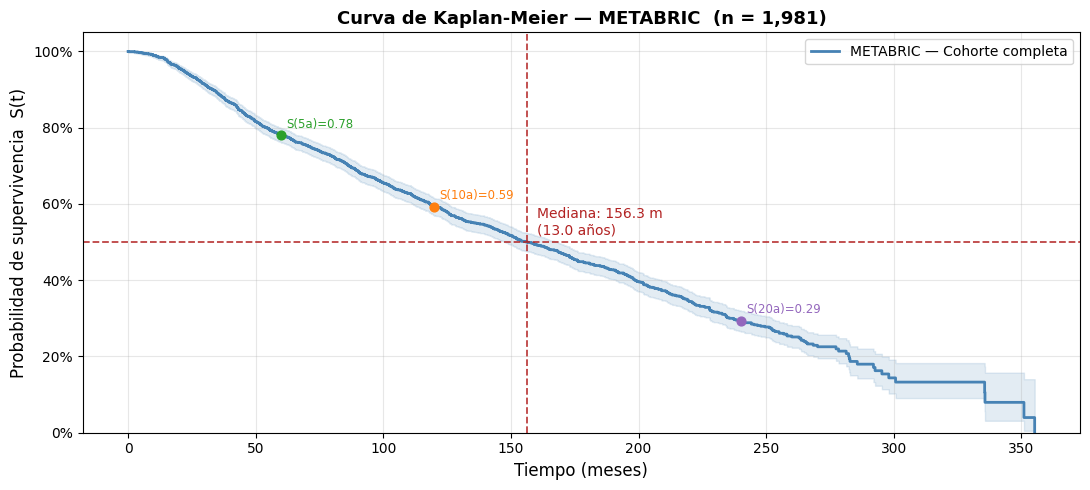

In [30]:
kmf_global = KM.fit_km_global(dur_all, evt_all, label='METABRIC — Cohorte completa')

display(KM.km_metrics(kmf_global, horizons=[60, 120, 180, 240]))

KM.plot_km_global(
    kmf_global,
    n_total     = len(df_km),
    output_path = r'../images/Modelos/KM/KM_global.png'
)

**Interpretación de la Curva de Supervivencia Global:**

La curva Kaplan-Meier global muestra el comportamiento agregado de supervivencia de la cohorte METABRIC. 

La mediana de supervivencia estimada se sitúa en torno a 156 meses, equivalente aproximadamente a 13 años. La supervivencia estimada a 5 años es cercana al 78%, disminuye hasta aproximadamente el 59% a 10 años y continúa descendiendo en los horizontes posteriores. Esta evolución es coherente con una cohorte de cáncer de mama con seguimiento prolongado y mezcla de subtipos clínicos y moleculares.

La cola final de la curva debe interpretarse con cautela. Aunque METABRIC dispone de seguimiento muy extenso, los intervalos temporales más tardíos se estiman con un número cada vez menor de pacientes en riesgo, lo que incrementa la incertidumbre de la estimación. Por este motivo, para la evaluación predictiva mediante Brier Score se utilizará posteriormente un intervalo temporal restringido a percentiles centrales del seguimiento.

#### **D. Evaluación pronóstica univariante mediante log-rank**

A continuación, se aplica el test log-rank de forma univariante sobre variables clínicas, histopatológicas, moleculares y terapéuticas. El objetivo no es realizar selección definitiva de variables, sino identificar qué dimensiones de la cohorte producen diferencias visibles y estadísticamente relevantes en las curvas de supervivencia.

Se incluyen tanto variables categóricas originales como variables continuas discretizadas para este análisis. Los valores ausentes se excluyen variable a variable, por lo que el tamaño muestral analizado puede variar entre contrastes.

Dado que se realizan múltiples pruebas, se informa tanto el valor $p$ crudo como el valor $q$ corregido mediante Benjamini-Hochberg FDR.

In [31]:
# =============================================================================
# Test log-rank univariante
# =============================================================================
VARS_LOGRANK = [
    # Biomarcadores moleculares
    'ER Status',
    'ER status measured by IHC',
    'PR Status',
    'HER2 Status',
    'HER2 status measured by SNP6',
    'Pam50 + Claudin-low subtype',
    '3-Gene classifier subtype',
    'Integrative Cluster',
    # Patología tumoral — categóricas originales
    'Cancer Type Detailed',
    'Tumor Other Histologic Subtype',
    'Cellularity',
    # Patología tumoral — discretizadas
    'Tumor Stage Cat',
    'Histologic Grade Cat',
    'Nodal Status',
    'NPI Group',
    # Terapéuticas
    'Chemotherapy',
    'Hormone Therapy',
    'Radio Therapy',
    'Type of Breast Surgery',
    # Clínico-demográficas — categóricas originales
    'Inferred Menopausal State',
    'Primary Tumor Laterality',
    # Clínico-demográficas — discretizadas
    'Age Group',
    # Moleculares — discretizadas
    'Mutation Burden',
]

tabla_lr = KM.logrank_summary(df_km, VARS_LOGRANK)
display(tabla_lr)

,Variable,k grupos,chi²,p-valor,Significancia
0,3-Gene classifier subtype,4,40.871,0.000000,***
1,Integrative Cluster,11,72.636,0.000000,***
2,Pam50 + Claudin-low subtype,7,56.036,0.000000,***
3,Tumor Stage Cat,5,128.221,0.000000,***
4,Nodal Status,4,205.501,0.000000,***
5,NPI Group,3,156.127,0.000000,***
6,Type of Breast Surgery,2,49.552,0.000000,***
7,Inferred Menopausal State,2,40.349,0.000000,***
8,Age Group,5,201.502,0.000000,***
9,Histologic Grade Cat,3,26.399,0.000008,***


**Interpretación de los Resultados del Test:**

De las 23 variables evaluadas, 18 demostraron poseer capacidad de estratificación pronóstica estadísticamente significativa ($p < 0.05$). Destacan de forma contundente (con $p \approx 0.00$) factores anatómicos asociados a la agresividad mecánica del tumor (`Tumor Stage Cat` y `Nodal Status`) y la edad (`Age Group`). Asimismo, los subtipos moleculares (`Pam50` e `Integrative Cluster`) dividen de manera drástica las curvas de supervivencia, capturando la heterogeneidad intrínseca del cáncer de mama.

Es de notable interés analítico que la variable `Mutation Burden` (carga mutacional) no resultara significativa de forma aislada ($p=0.7667$). Esto sugiere que, a diferencia de tumores altamente inmunogénicos (como el de pulmón), la cantidad cruda de mutaciones en el cáncer de mama primario no parece ser un factor determinante directo de la supervivencia sin la interacción de otras variables clínicas.

#### **F. Análisis Visual de Curvas Kaplan-Meier por Familia Clínica**

El test de log-rank cuantifica si hay diferencias, pero la visualización de las curvas de Kaplan-Meier permite comprender la *dinámica temporal* de esas diferencias. A continuación, se analizan los hallazgos agrupados por contexto clínico:

##### **I. Perfil Clínico-Demográfico**

La variable `Age Group` evidencia que la supervivencia decae de forma escalonada a medida que avanza la edad al diagnóstico, siendo el grupo de mayores de 70 años el de peor pronóstico con diferencia. Este efecto está íntimamente ligado al `Estado Menopáusico`, donde las pacientes postmenopáusicas muestran peor supervivencia. Por otro lado, la variable `Lateralidad del Tumor` (mama izquierda vs. derecha) presenta curvas prácticamente superpuestas ($p=0.71$), confirmando que la localización anatómica simétrica no influye en la biología de la enfermedad ni en el pronóstico.

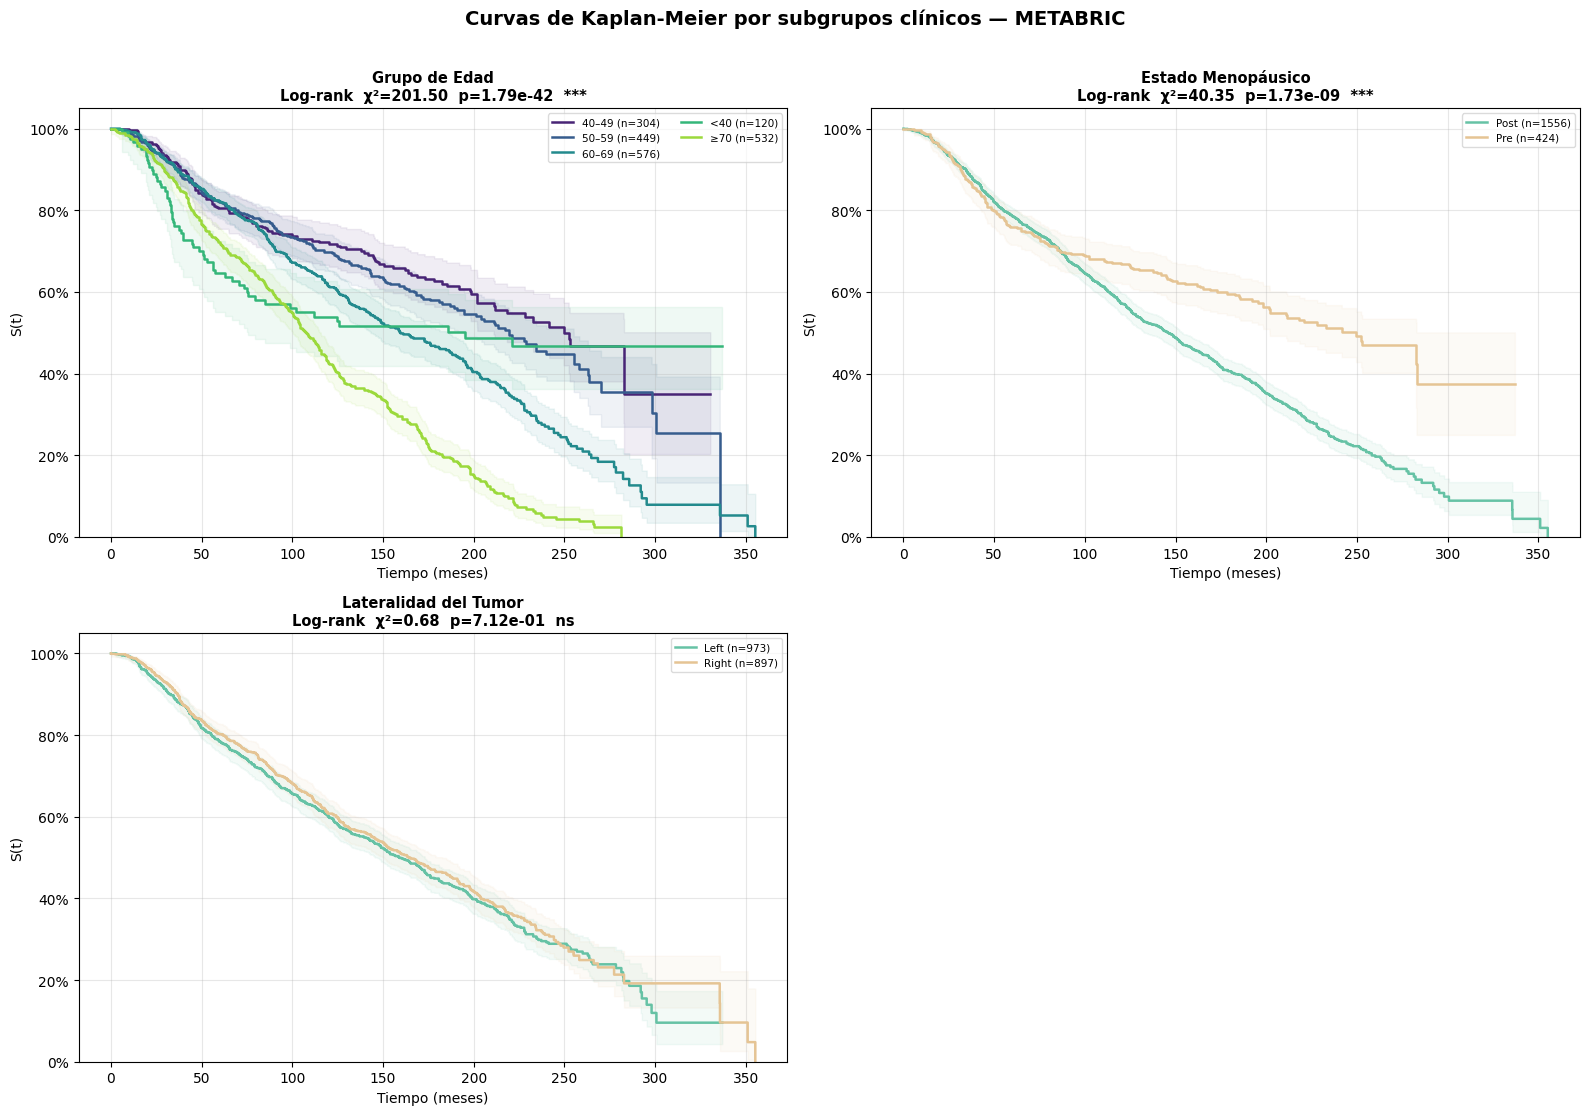

In [111]:
KM.plot_km_groups(
    df = df_km,
    grupos_config = {
        'Grupo de Edad'               : ('Age Group',                'viridis'),
        'Estado Menopáusico'          : ('Inferred Menopausal State','Set2'),
        'Lateralidad del Tumor'       : ('Primary Tumor Laterality', 'Set2'),
    },
    ncols       = 2,
    output_path = r'../images/Modelos/KM/KM_demografico.png'
)

##### **II. Estadificación y Patología (Carga tumoral)**

Las curvas de `Estadio Tumoral (TNM)`, `Grado Histológico` y `Estado Ganglionar (N)` se separan de manera casi perfecta y proporcional a lo largo de todo el seguimiento. Un paciente en Estadio 0/1 o sin ganglios afectados (N0) mantiene una probabilidad de supervivencia superior al 80% a los 10 años, mientras que aquellos con 10 o más ganglios afectados (N3) o Grado 3 ven su curva desplomarse drásticamente en los primeros 5 años. Esta separación sin cruces sugiere fuertemente que estas variables cumplirán el supuesto de riesgos proporcionales necesario para el posterior modelo de Cox.

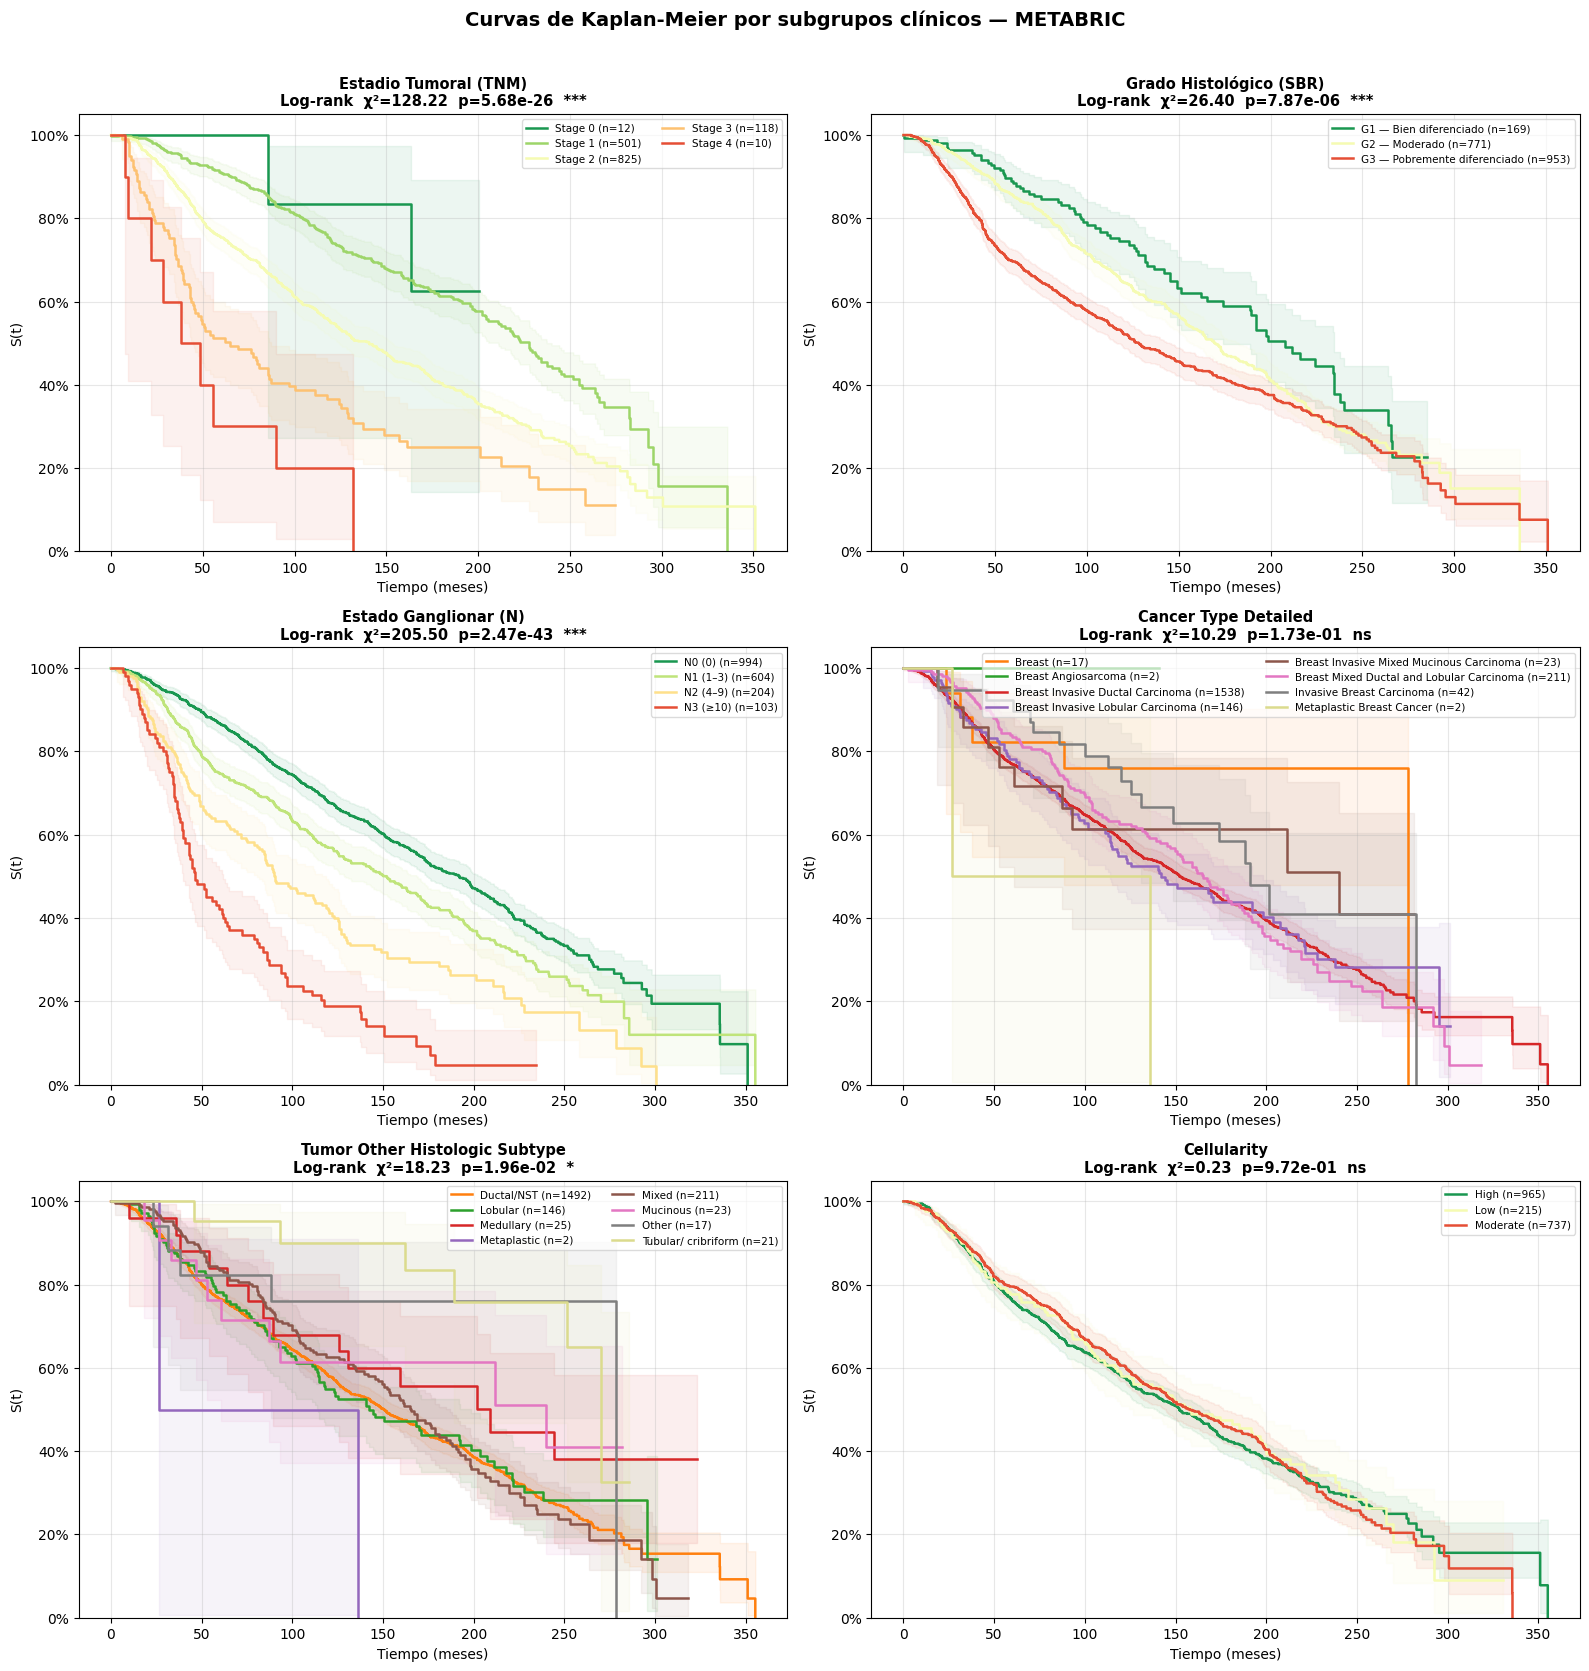

In [112]:
KM.plot_km_groups(
    df = df_km,
    grupos_config = {
        'Estadio Tumoral (TNM)'         : ('Tumor Stage Cat',              'RdYlGn_r'),
        'Grado Histológico (SBR)'       : ('Histologic Grade Cat',         'RdYlGn_r'),
        'Estado Ganglionar (N)'         : ('Nodal Status',                 'RdYlGn_r'),
        'Cancer Type Detailed'          : ('Cancer Type Detailed',         'tab20'),
        'Tumor Other Histologic Subtype': ('Tumor Other Histologic Subtype','tab20'),
        'Cellularity'                   : ('Cellularity',                  'RdYlGn_r'),
    },
    ncols       = 2,
    output_path = r'../images/Modelos/KM/KM_estadificacion_patologia.png'
)

##### **III. Biomarcadores de Receptor**

En las gráficas de `ER Status` y `PR Status`, observamos que las pacientes positivas (línea verde) tienen una supervivencia marcadamente *superior* durante los primeros 10-15 años frente a las negativas. Sin embargo, a partir del mes 150-200, las curvas convergen y llegan a cruzarse, indicando que los tumores Luminales (ER+) presentan un riesgo sostenido de recaída y mortalidad a muy largo plazo. Mientras que los tumores negativos tienen una mortalidad muy alta y temprana, pero si superan los primeros años, su riesgo de evento cae drásticamente. 

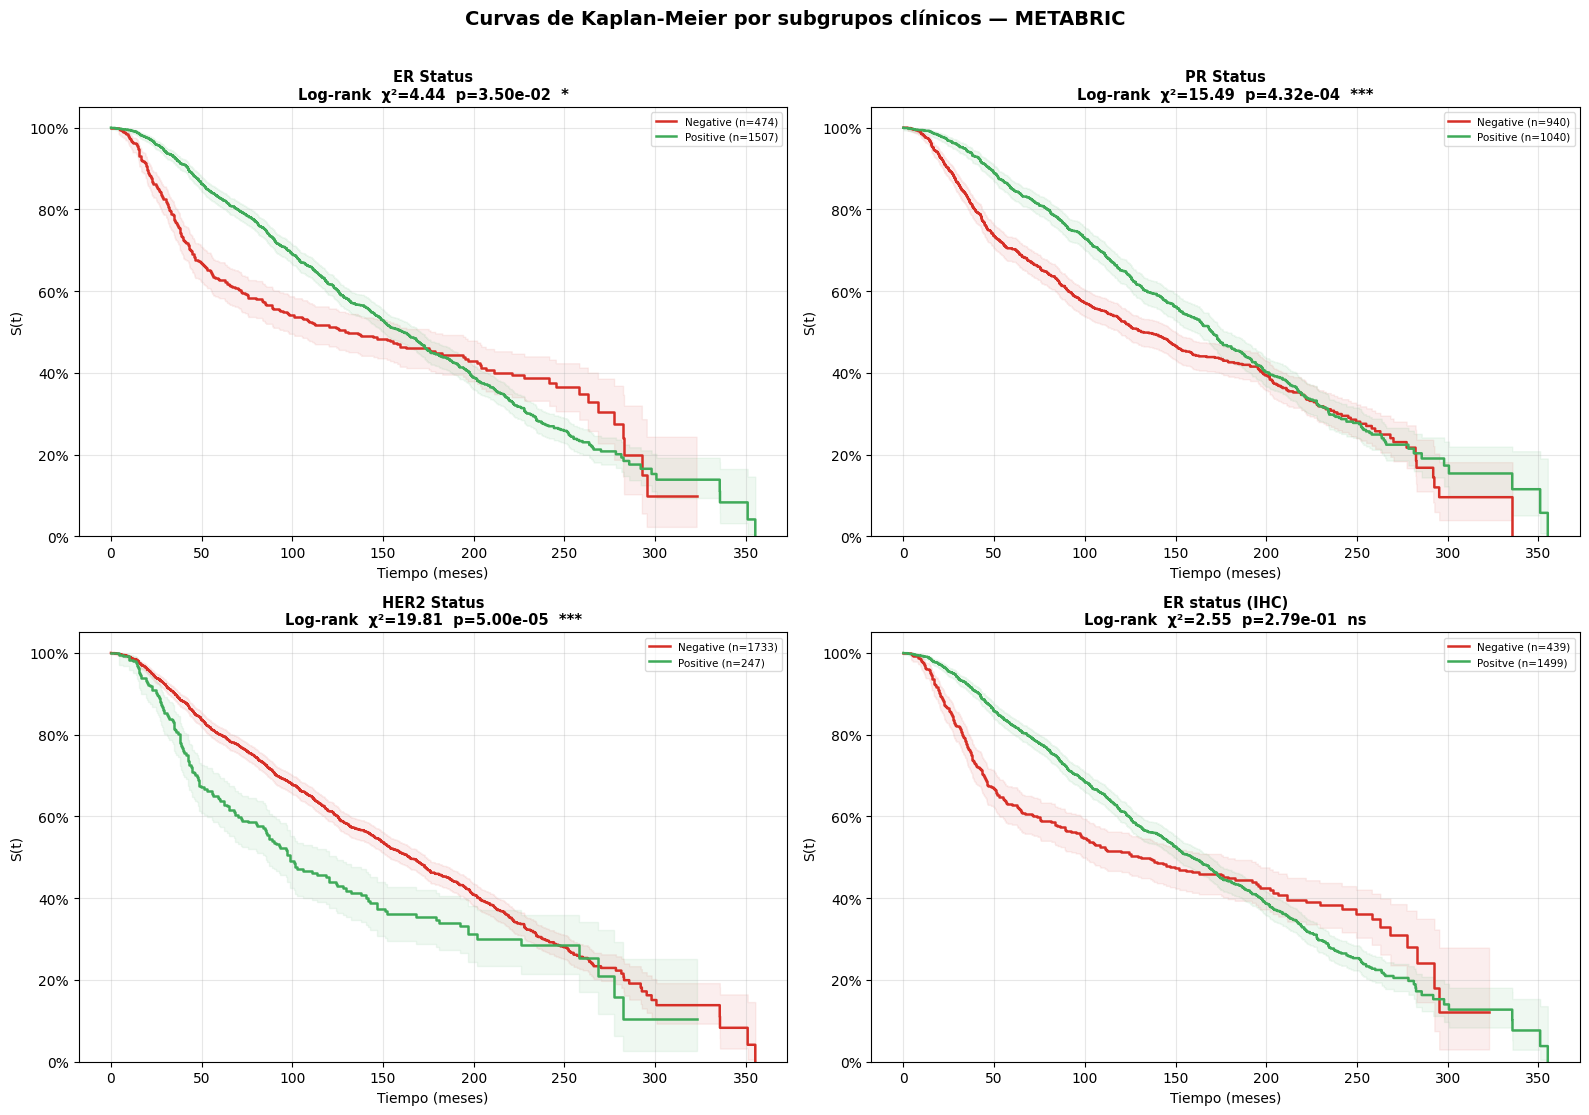

In [113]:
KM.plot_km_groups(
    df      = df_km,
    grupos_config = {
        'ER Status'               : ('ER Status',               'RdYlGn'),
        'PR Status'               : ('PR Status',               'RdYlGn'),
        'HER2 Status'             : ('HER2 Status',             'RdYlGn'),
        'ER status (IHC)'         : ('ER status measured by IHC','RdYlGn'),
    },
    ncols       = 2,
    output_path = r'../images/Modelos/KM/KM_receptores.png'
)

##### IV. Subtipos Moleculares

Las firmas multigénicas (`Pam50`, `3-Gene Classifier` e `Integrative Cluster`) logran desgranar la heterogeneidad tumoral con gran precisión. En el gráfico de `Pam50`, destaca la rápida caída inicial de los subtipos *Her2* y *Basal*, en contraste con la caída más suave y prolongada del subtipo *Luminal A*. El `Integrative Cluster`, al dividir la cohorte en 10 subgrupos, genera un abanico que, aunque visualmente denso, resalta la variable agresividad intrínseca del cáncer de mama.

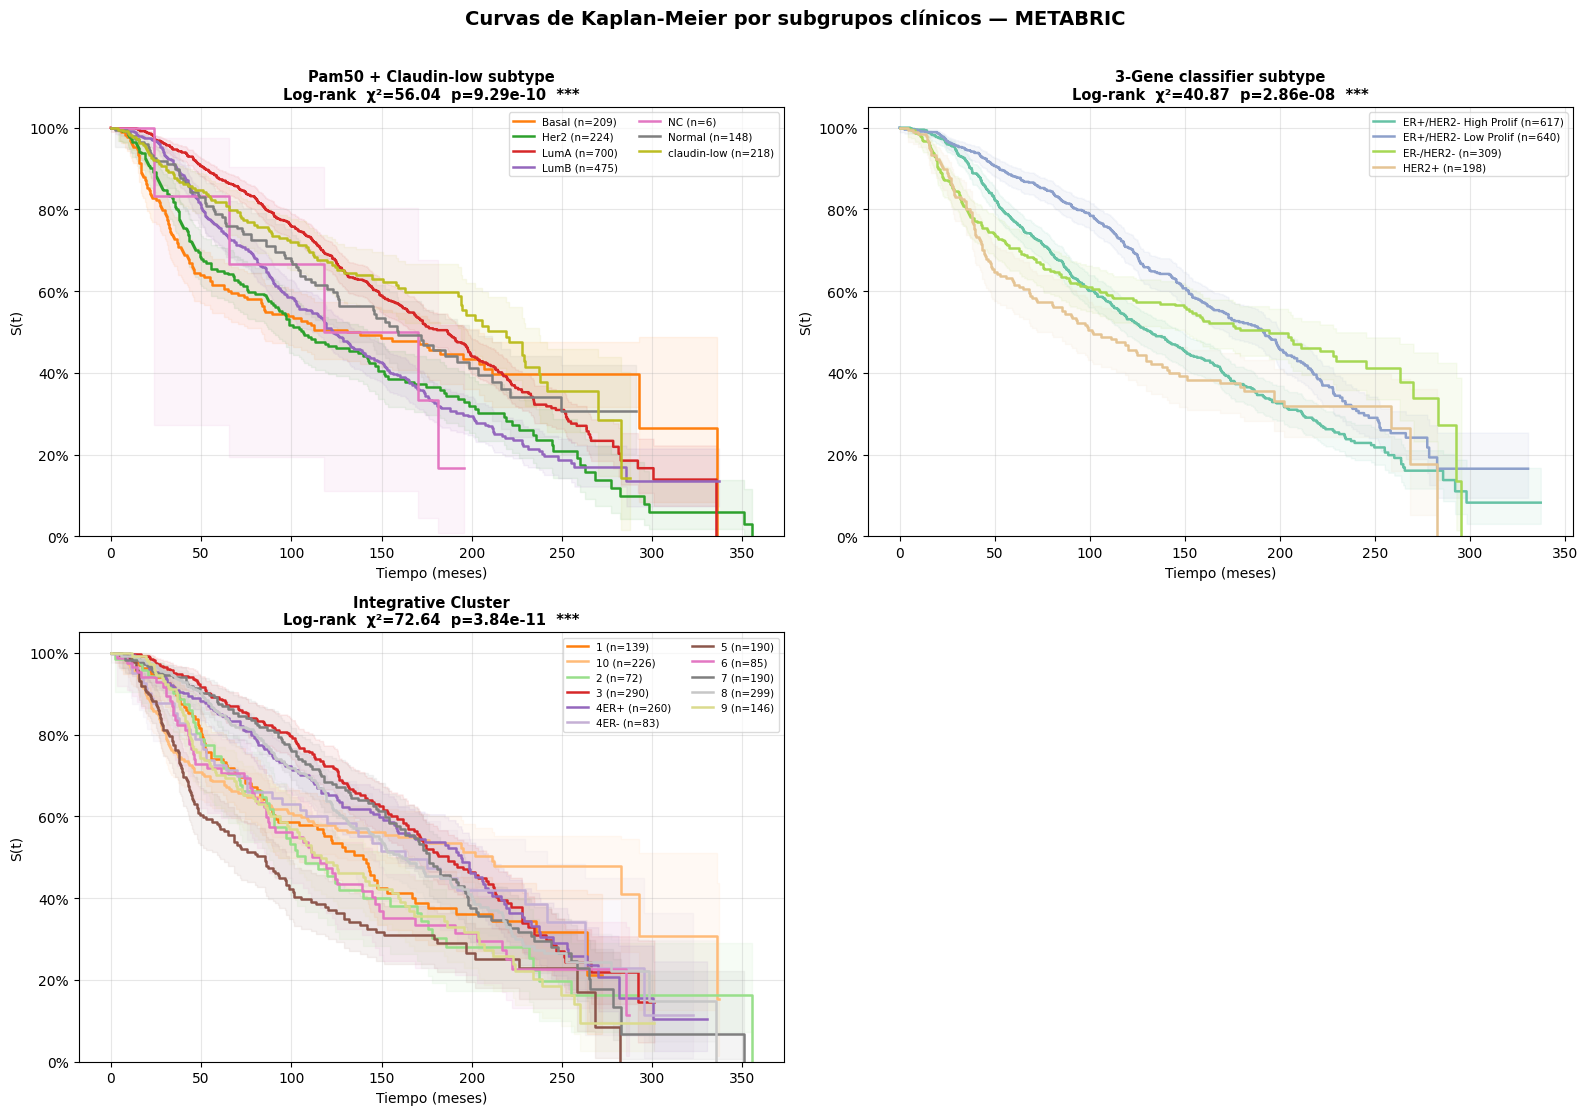

In [114]:
KM.plot_km_groups(
    df      = df_km,
    grupos_config = {
        'Pam50 + Claudin-low subtype' : ('Pam50 + Claudin-low subtype', 'tab10'),
        '3-Gene classifier subtype'   : ('3-Gene classifier subtype',   'Set2'),
        'Integrative Cluster'         : ('Integrative Cluster',         'tab20'),
    },
    ncols       = 2,
    output_path = r'../images/Modelos/KM/KM_subtipos_moleculares.png'
)

##### V. Intervenciones Terapéuticas 

Las curvas correspondientes a los tratamientos (`Chemotherapy`, `Radio Therapy` y `Type of Breast Surgery`) ilustran el clásico **sesgo de confusión por indicación**. A simple vista, las gráficas sugieren contraintuitivamente que recibir quimioterapia o someterse a una mastectomía confiere *peor* supervivencia que no hacerlo o recibir cirugía conservadora. Clínicamente, esto no significa que el tratamiento sea perjudicial, sino que la quimioterapia y la cirugía radical se prescriben precisamente a pacientes que ya presentan tumores más grandes, de mayor grado o con ganglios positivos (peor pronóstico basal). 

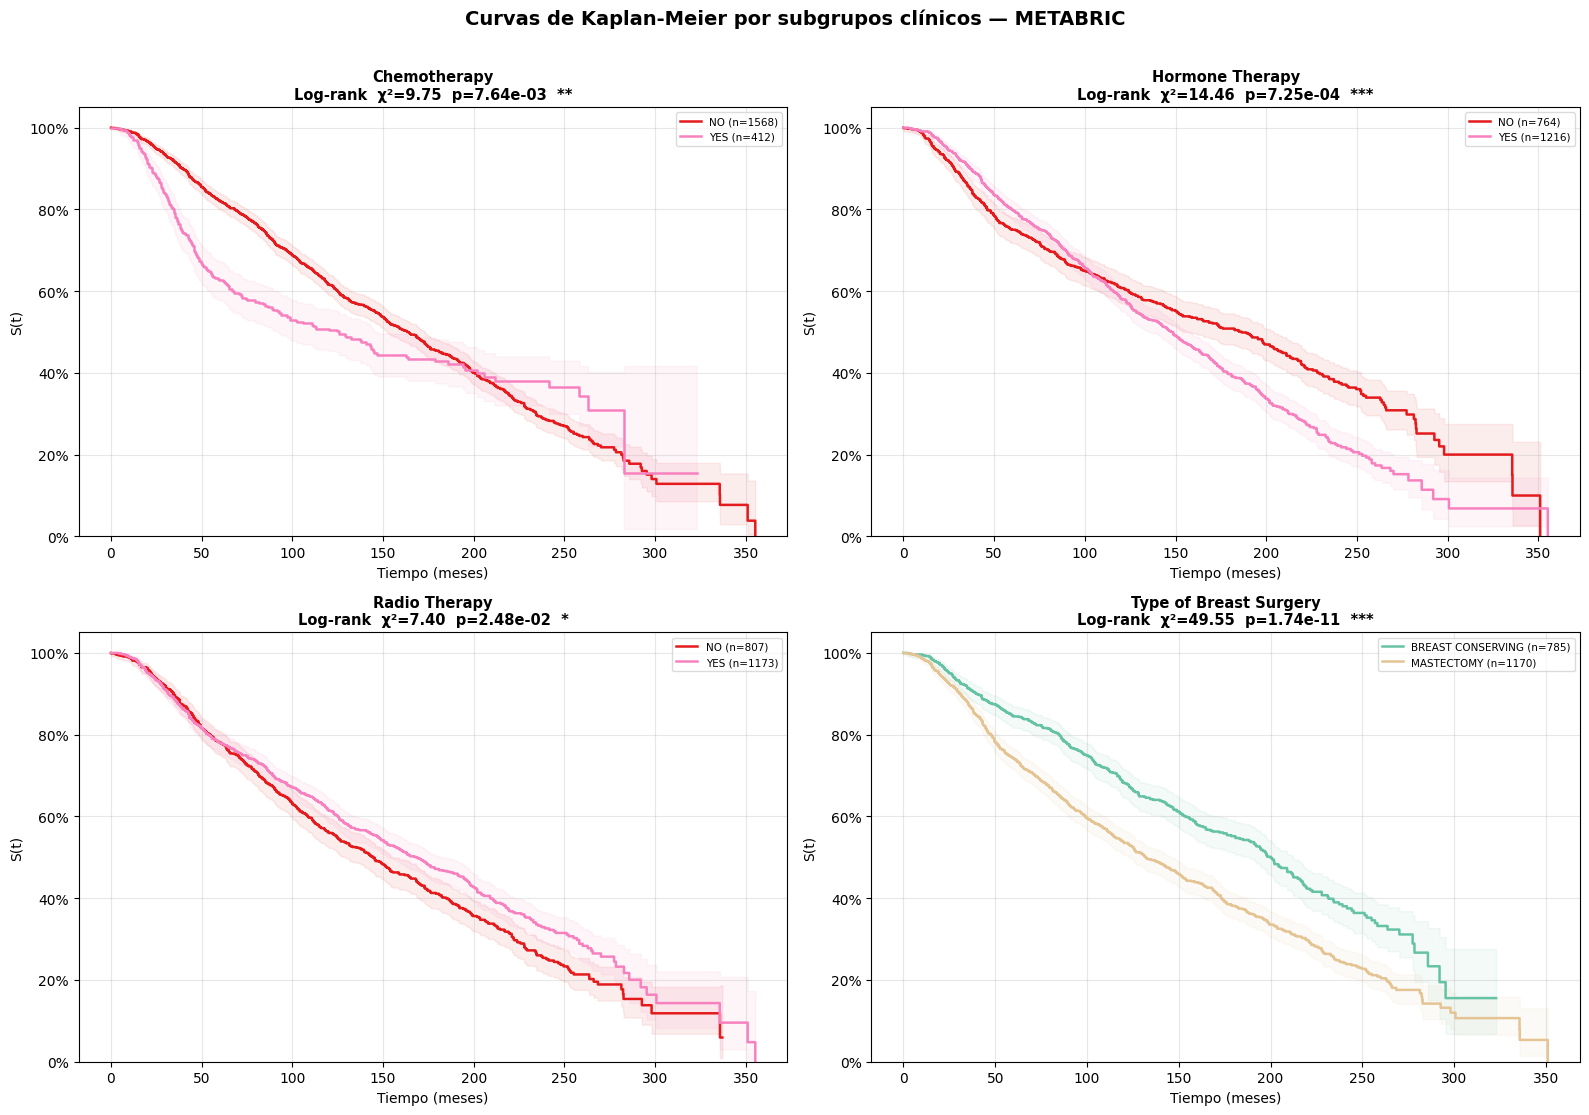

In [115]:
KM.plot_km_groups(
    df      = df_km,
    grupos_config = {
        'Chemotherapy'        : ('Chemotherapy',       'Set1'),
        'Hormone Therapy'     : ('Hormone Therapy',    'Set1'),
        'Radio Therapy'       : ('Radio Therapy',      'Set1'),
        'Type of Breast Surgery': ('Type of Breast Surgery', 'Set2'),
    },
    ncols       = 2,
    output_path = r'../images/Modelos/KM/KM_tratamientos.png'
)

> *Estos gráficos justifican categóricamente por qué el análisis univariante es insuficiente y hace imprescindible el uso de modelos multivariantes (Cox, RSF, DeepSurv) para ajustar el efecto del tratamiento por la gravedad subyacente de la enfermedad.*

#### **F. Kaplan-Meier como modelo basal para Brier Score**

Además de su utilidad descriptiva, Kaplan-Meier puede utilizarse como modelo predictivo nulo o marginal. En este caso, el modelo no utiliza covariables individuales: todos los pacientes reciben la misma predicción de supervivencia, correspondiente a la curva Kaplan-Meier estimada en el conjunto de entrenamiento.

Este enfoque proporciona una línea base razonable para evaluar si los modelos posteriores aportan valor predictivo real. Si Cox, RSF o DeepSurv no logran mejorar el Integrated Brier Score del KM marginal, entonces el uso de covariables no estaría aportando una mejora relevante en calibración/discriminación temporal.

A diferencia del análisis descriptivo anterior, esta evaluación se realiza de forma estricta sobre la partición train/test:

1. Se ajusta Kaplan-Meier únicamente con `dur_train` y `evt_train`.
2. Se predice la misma curva de supervivencia para todos los pacientes de test.
3. Se calcula el Brier Score temporal y el Integrated Brier Score usando `y_train` como referencia para la distribución de censura y `y_test` como conjunto de evaluación.

Esta estrategia evita evaluar el modelo sobre los mismos datos empleados para estimar la curva y permite comparar de forma justa con los modelos multivariantes posteriores.

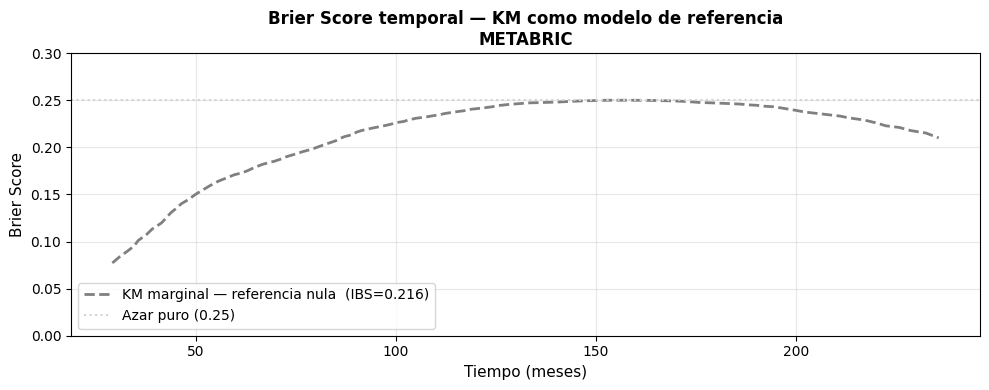

IBS — KM marginal (referencia nula) : 0.2156
  -> Cualquier modelo con IBS < 0.2156 mejora sobre la referencia KM


In [116]:
y_all      = Surv.from_arrays(evt_all.astype(bool), dur_all.astype(float))
times_ref  = np.percentile(dur_all, np.linspace(10, 90, 100))
times_ref  = times_ref[(times_ref > dur_all.min()) & (times_ref < dur_all.max())]

# Misma S(t) para todos los pacientes en cada instante
km_surv_probs = np.tile(
    kmf_global.predict(times_ref),
    (len(df_km), 1)
)

_, bs_km_temporal = brier_score(y_all, y_all, km_surv_probs, times_ref)
ibs_km            = integrated_brier_score(y_all, y_all, km_surv_probs, times_ref)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_ref, bs_km_temporal, color='gray', linewidth=2,
        linestyle='--', label=f'KM marginal — referencia nula  (IBS={ibs_km:.3f})')
ax.axhline(0.25, color='lightgray', linestyle=':', linewidth=1.5,
           label='Azar puro (0.25)')
ax.set_xlabel('Tiempo (meses)', fontsize=11)
ax.set_ylabel('Brier Score', fontsize=11)
ax.set_title('Brier Score temporal — KM como modelo de referencia\nMETABRIC',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 0.30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'../images/Modelos/KM/KM_brier_referencia.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"IBS — KM marginal (referencia nula) : {ibs_km:.4f}")
print(f"  -> Cualquier modelo con IBS < {ibs_km:.4f} mejora sobre la referencia KM")

#### **G. Síntesis del análisis Kaplan-Meier**

El análisis Kaplan-Meier permite extraer varias conclusiones relevantes para la continuación del modelado:

1. La cohorte METABRIC presenta un seguimiento largo y una proporción suficiente de eventos, lo que la convierte en una base adecuada para modelos de supervivencia.

2. La supervivencia global estimada reproduce un patrón clínicamente plausible para cáncer de mama, con mediana de supervivencia prolongada y descenso progresivo a lo largo del seguimiento.

3. Las variables de estadificación y carga tumoral, especialmente estado ganglionar, estadio tumoral y NPI, muestran una fuerte capacidad de estratificación univariante.

4. Las clasificaciones moleculares, como PAM50 e Integrative Cluster, separan de forma clara las curvas de supervivencia, reforzando la hipótesis central del TFM: la información molecular puede aportar valor pronóstico más allá de las variables clínicas tradicionales.

5. Las variables terapéuticas muestran asociaciones relevantes, pero no deben interpretarse causalmente por la presencia de confusión por indicación.

6. Las variables no significativas en log-rank, como lateralidad o carga mutacional discretizada, no se descartan automáticamente. Su contribución ajustada podrá evaluarse en modelos multivariantes y no lineales.

7. El Integrated Brier Score del KM marginal proporciona una línea base objetiva para los modelos posteriores. Cox, RSF y DeepSurv deberán mejorar este valor para justificar el uso de covariables y mayor complejidad metodológica.

En la siguiente sección se implementará el modelo de Cox penalizado, que permitirá pasar de un análisis univariante descriptivo a un enfoque multivariante capaz de estimar el efecto ajustado de las covariables sobre el riesgo de muerte.

### **3.4.2. Modelo de Riesgos Proporcionales de Cox (Cox PH)**

#### **A. Fundamentos Teóricos**

El modelo de riesgos proporcionales de Cox (Cox, 1972) es el modelo de regresión de supervivencia más utilizado en investigación clínica. A diferencia del estimador de Kaplan-Meier, que describe la supervivencia de forma no paramétrica sin incorporar covariables, Cox permite cuantificar el efecto simultáneo de múltiples factores pronósticos sobre el riesgo de un evento, manteniendo la flexibilidad de no asumir ninguna distribución paramétrica para el tiempo hasta el evento.

##### **I. La Función de Riesgo (Hazard Function)**

El modelo se formula en términos de la **función de riesgo instantáneo** $h(t \mid \mathbf{x})$, que representa la tasa de ocurrencia del evento en el instante $t$ dado que el individuo ha sobrevivido hasta ese momento y posee un vector de covariables $\mathbf{x} = (x_1, x_2, \ldots, x_p)$:

$$h(t \mid \mathbf{x}) = h_0(t) \cdot \exp\!\left(\sum_{k=1}^{p} \beta_k x_k\right) = h_0(t) \cdot \exp(\boldsymbol{\beta}^\top \mathbf{x})$$

donde:
- $h_0(t)$ es el **riesgo basal** (*baseline hazard*): , una función no paramétrica que describe cómo cambia el riesgo en el tiempo para un paciente con todas las covariables a valor cero. Cox nunca la estima directamente; por eso el modelo se denomina **semi-paramétrico**.
- $\exp(\boldsymbol{\beta}^\top \mathbf{x})$ representa el Hazard Ratio (HR) para la covariable $X_i$. Un HR > 1 indica un aumento del riesgo de muerte (peor pronóstico), mientras que un HR < 1 indica un factor protector.
- $\boldsymbol{\beta} = (\beta_1, \ldots, \beta_p)$ son los **coeficientes de regresión**, los parámetros que el modelo estima.

##### **II. El Supuesto de Proporcionalidad**

La hipótesis central del modelo es que el cociente de riesgos entre dos individuos con covariables $\mathbf{x}_i$ y $\mathbf{x}_j$ es **constante en el tiempo**:

$$\frac{h(t \mid \mathbf{x}_i)}{h(t \mid \mathbf{x}_j)} = \frac{h_0(t) \cdot \exp(\boldsymbol{\beta}^\top \mathbf{x}_i)}{h_0(t) \cdot \exp(\boldsymbol{\beta}^\top \mathbf{x}_j)} = \exp\!\left(\boldsymbol{\beta}^\top (\mathbf{x}_i - \mathbf{x}_j)\right)$$

El riesgo basal $h_0(t)$ se cancela, lo que significa que el **Hazard Ratio (HR)** entre dos perfiles no depende del tiempo $t$. Esta es la propiedad de *proporcionalidad de riesgos*, que deberá verificarse empíricamente en el apartado D mediante los residuos de Schoenfeld.

El **Hazard Ratio** asociado a una covariable $x_k$ se interpreta directamente como:

$$HR_k = \exp(\beta_k)$$

Un $HR_k > 1$ indica que un incremento unitario en $x_k$ aumenta el riesgo (peor pronóstico); $HR_k < 1$ indica efecto protector; $HR_k = 1$ indica ausencia de efecto.

##### **III. Estimación: Verosimilitud Parcial de Cox**

Una de las contribuciones más elegantes de Cox (1972) fue demostrar que $\boldsymbol{\beta}$ puede estimarse sin necesidad de especificar $h_0(t)$, mediante la **verosimilitud parcial**. Para cada instante $t_j$ en que ocurre un evento, se define el conjunto de riesgo $\mathcal{R}(t_j)$ como el conjunto de individuos que aún no han tenido el evento ni han sido censurados justo antes de $t_j$. La verosimilitud parcial es:

$$\mathcal{L}(\boldsymbol{\beta}) = \prod_{j: \delta_j = 1} \frac{\exp(\boldsymbol{\beta}^\top \mathbf{x}_j)}{\sum_{l \in \mathcal{R}(t_j)} \exp(\boldsymbol{\beta}^\top \mathbf{x}_l)}$$

donde $\delta_j = 1$ indica que el individuo $j$ sufrió el evento (no está censurado). El numerador recoge la contribución del individuo que experimentó el evento; el denominador suma las contribuciones de todos los individuos en riesgo en ese instante, capturando la competencia por el evento.

La estimación de $\hat{\boldsymbol{\beta}}$ se obtiene maximizando el logaritmo de esta expresión mediante optimización numérica (habitualmente descenso de gradiente o Newton-Raphson). La ausencia de $h_0(t)$ en esta expresión es lo que le confiere al modelo su carácter semi-paramétrico y su robustez frente a la elección de una distribución de tiempos.

> **Nota sobre empates (*ties*):** En datos clínicos con tiempos registrados en meses enteros (como METABRIC), los empates son frecuentes. Se empleará la **aproximación de Breslow** (implementada por defecto en `lifelines`), que ajusta el denominador de la verosimilitud parcial para manejar múltiples eventos en el mismo instante de tiempo.

##### **IV. Estimación de la Función de Supervivencia**

Una vez estimados $\hat{\boldsymbol{\beta}}$, la función de supervivencia para un individuo con covariables $\mathbf{x}$ se obtiene a través del estimador de Nelson-Aalen para el riesgo acumulado basal $\hat{H}_0(t)$:

$$\hat{S}(t \mid \mathbf{x}) = \exp\!\left(-\hat{H}_0(t) \cdot \exp(\hat{\boldsymbol{\beta}}^\top \mathbf{x})\right)$$

Esta es la curva de supervivencia individualizada que el modelo producirá para cada paciente del conjunto de test, y que permitirá calcular el **Brier Score integrado (IBS)** para comparar con la línea base de KM (IBS$_{\text{ref}}$ = 0.2156).

#### **B. Selección de Variables para el Modelo de Cox**

Antes de ajustar el modelo, es necesario reducir el espacio de covariables de las 70 generadas tras el preprocesado. Un modelo de Cox con 70 predictores sobre 1.584 observaciones y una tasa de eventos del 57.77% (≈916 eventos) no viola formalmente la regla empírica de 10–15 eventos por variable (EPV), pero introduce dos problemas prácticos: **multicolinealidad** entre variables derivadas del mismo constructo clínico, y **ruido** por inclusión de variables sin valor pronóstico demostrado. El análisis KM del apartado anterior orienta directamente ambas decisiones.

##### **I. Exclusión por ausencia de valor pronóstico (test log-rank)**

Las variables identificadas en el análisis log-rank como no significativas ($p \geq 0.05$) o redundantes se eliminan del espacio de covariables. Adicionalmente, se excluyen variables que introducirían **confusión por indicación**: los tratamientos recibidos (`Chemotherapy`, `Hormone Therapy`, `Radio Therapy`) no son covariables pronósticas independientes en este contexto, ya que su administración está determinada por el estadio y el subtipo tumoral. Incluirlas en un modelo no experimental produce coeficientes no causales difíciles de interpretar.

In [ ]:
EXCLUIR_PREFIJOS = [
    # Sin valor pronóstico univariante (log-rank ns)
    'Cellularity',
    'Primary Tumor Laterality',
    'ER status measured by IHC',   # redundante con ER Status
    'Cancer Type Detailed',
    'Oncotree Code',               # codifica lo mismo que Cancer Type Detailed
    'Tumor Other Histologic Subtype',  # p=0.020 marginal + redundante con Cancer Type Detailed
    # Confusión por indicación
    'Chemotherapy',
    'Hormone Therapy',
    'Radio Therapy',
    # Identificadores / constantes (ya excluidas en preprocesado, verificación)
    'Study ID', 'Patient ID', 'Sample ID',
]

# Identificar columnas a eliminar (coincidencia exacta o por prefijo OHE)
cols_excluir = [
    col for col in X_train.columns
    if any(col == prefijo or col.startswith(prefijo + '_') for prefijo in EXCLUIR_PREFIJOS)
]

print(f"Columnas eliminadas ({len(cols_excluir)}):")
for c in cols_excluir:
    print(f"  - {c}")

Columnas eliminadas (28):
  · Cancer Type Detailed_Breast Angiosarcoma
  · Cancer Type Detailed_Breast Invasive Ductal Carcinoma
  · Cancer Type Detailed_Breast Invasive Lobular Carcinoma
  · Cancer Type Detailed_Breast Invasive Mixed Mucinous Carcinoma
  · Cancer Type Detailed_Breast Mixed Ductal and Lobular Carcinoma
  · Cancer Type Detailed_Invasive Breast Carcinoma
  · Cancer Type Detailed_Metaplastic Breast Cancer
  · Cellularity_Low
  · Cellularity_Moderate
  · Cellularity_Unknown
  · Chemotherapy_Unknown
  · Chemotherapy_YES
  · ER status measured by IHC_Positve
  · ER status measured by IHC_Unknown
  · Tumor Other Histologic Subtype_Lobular
  · Tumor Other Histologic Subtype_Medullary
  · Tumor Other Histologic Subtype_Metaplastic
  · Tumor Other Histologic Subtype_Mixed
  · Tumor Other Histologic Subtype_Mucinous
  · Tumor Other Histologic Subtype_Other
  · Tumor Other Histologic Subtype_Tubular/ cribriform
  · Tumor Other Histologic Subtype_Unknown
  · Hormone Therapy_Unknown

##### **II. Gestión de la multicolinealidad estructural: NPI vs. sus componentes**

El **Índice Pronóstico de Nottingham (NPI)** se define como combinación lineal de tres variables presentes también de forma independiente en el dataset:

$$\text{NPI} = 0.2 \times \text{Tumor Size} + \text{Nodal Stage} + \text{Histologic Grade}$$

Incluir simultáneamente el NPI y sus tres componentes crea una **multicolinealidad perfecta por construcción**, que inflaría los errores estándar de los coeficientes e impediría la convergencia del optimizador. La decisión se toma en favor de mantener los **componentes individuales** (`Tumor Size`, `Lymph nodes examined positive`, `Neoplasm Histologic Grade`) y descartar el NPI, por dos razones:

1. Los componentes aportan información diferenciada en un modelo multivariante (el peso de cada uno puede diferir de los pesos fijos del NPI).
2. El NPI fue diseñado para un contexto univariante; en regresión multivariante, los coeficientes se reestiman libremente.

In [28]:
EXCLUIR_PREFIJOS += ['Nottingham prognostic index']

# Regenerar la lista completa de exclusiones
cols_excluir = [
    col for col in X_train.columns
    if any(col == prefijo or col.startswith(prefijo + '_') for prefijo in EXCLUIR_PREFIJOS)
]

#### **III. Diagnóstico de multicolinealidad residual — Factor de Inflación de Varianza (VIF)**

Tras la exclusión manual, se calcula el **VIF** para detectar multicolinealidad residual entre las variables numéricas continuas. Un VIF > 10 indica colinealidad severa que puede desestabilizar los coeficientes de Cox.


In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Aplicar exclusiones y quedarnos solo con numéricas para el VIF
X_cox = X_train.drop(columns=cols_excluir, errors='ignore')
X_cox_test = X_test.drop(columns=cols_excluir, errors='ignore')

num_cols_cox = X_cox.select_dtypes(include='number').columns.tolist()

vif_data = pd.DataFrame({
    'Variable': num_cols_cox,
    'VIF': [
        variance_inflation_factor(X_cox[num_cols_cox].values, i)
        for i in range(len(num_cols_cox))
    ]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_data.to_string(index=False))

                                      Variable       VIF
             Inferred Menopausal State_Unknown       inf
           Pam50 + Claudin-low subtype_Unknown       inf
          HER2 status measured by SNP6_Unknown       inf
                           HER2 Status_Unknown       inf
                             PR Status_Unknown       inf
                   Integrative Cluster_Unknown       inf
                            ER Status_Positive 14.433822
              Pam50 + Claudin-low subtype_LumA  9.136096
          HER2 status measured by SNP6_NEUTRAL  8.146573
              Pam50 + Claudin-low subtype_LumB  5.913135
                         Integrative Cluster_5  5.195283
                          HER2 Status_Positive  5.041966
               3-Gene classifier subtype_HER2+  4.624898
                   Nottingham prognostic index  4.420956
                            PR Status_Positive  3.510635
                         Integrative Cluster_3  3.466824
                         Integr

Variables con VIF > 10 se evalúan individualmente: si dos variables son redundantes se conserva la de mayor $\chi^2$ en el log-rank; si la colinealidad es estructural (p. ej. entre `ER Status` y `Inferred Menopausal State`) se documenta pero no necesariamente se elimina, ya que el modelo penalizado del apartado C la gestionará mediante regularización.


#### **IV. Dataset final para Cox**


In [25]:
print("═" * 60)
print("  SELECCIÓN DE VARIABLES — COX PH")
print("═" * 60)
print(f"  Covariables antes de selección  : {X_train.shape[1]}")
print(f"  Variables / prefijos excluidos  : {len(EXCLUIR_PREFIJOS)}")
print(f"  Columnas OHE eliminadas         : {len(cols_excluir)}")
print(f"  Covariables finales para Cox    : {X_cox.shape[1]}")
print(f"  Shape X_cox  (train)            : {X_cox.shape}")
print(f"  Shape X_cox_test (test)         : {X_cox_test.shape}")
print("═" * 60)

════════════════════════════════════════════════════════════
  SELECCIÓN DE VARIABLES — COX PH
════════════════════════════════════════════════════════════
  Covariables antes de selección  : 70
  Variables / prefijos excluidos  : 12
  Columnas OHE eliminadas         : 28
  Covariables finales para Cox    : 42
  Shape X_cox  (train)            : (1584, 42)
  Shape X_cox_test (test)         : (397, 42)
════════════════════════════════════════════════════════════


#### **C. Ajuste del Modelo**

Se implementan dos estrategias complementarias de ajuste. La elección no es arbitraria: responde a una tensión habitual en modelos clínicos con espacios de covariables moderadamente amplios.

El **Cox estándar** (máxima verosimilitud parcial sin restricciones) produce coeficientes insesgados e intervalos de confianza interpretables, pero es sensible a la multicolinealidad residual y tiende a sobreajustar cuando el número de predictores es elevado en relación con los eventos. El **Cox penalizado con Elastic Net** introduce un término de regularización que contrae los coeficientes de variables irrelevantes hacia cero (efecto Lasso) y estabiliza los de variables correlacionadas (efecto Ridge), a costa de un sesgo controlado que generalmente mejora la capacidad predictiva en test.

Ambos modelos se ajustan sobre el mismo `X_cox` / `y_train` y se evalúan sobre el mismo `X_cox_test` / `y_test`, lo que garantiza una comparación directa.

##### **I. Cox Estándar — `CoxPHFitter` (lifelines)**

`lifelines` espera un único DataFrame que contenga simultáneamente las covariables, la duración y el indicador de evento. Se construye ese DataFrame a partir de los arrays ya preparados.

In [30]:
# ── Diagnóstico: columnas con varianza cero o casi cero ──────────────────────
var_cols = X_cox.var()
cols_var_cero = var_cols[var_cols < 1e-6].index.tolist()

print(f"Columnas con varianza ≈ 0 eliminadas ({len(cols_var_cero)}):")
for c in cols_var_cero:
    print(f"  · {c}")

X_cox      = X_cox.drop(columns=cols_var_cero)
X_cox_test = X_cox_test.drop(columns=cols_var_cero, errors='ignore')

Columnas con varianza ≈ 0 eliminadas (0):


In [31]:
# ── Eliminar columnas _Unknown restantes (VIF = inf) ─────────────────────────
# Las columnas OHE sufijo _Unknown son combinación lineal perfecta del resto
# de dummies de su grupo (sum-to-one constraint). Se eliminan sistemáticamente.

cols_unknown = [c for c in X_cox.columns if c.endswith('_Unknown')]

print(f"Columnas '_Unknown' eliminadas ({len(cols_unknown)}):")
for c in cols_unknown:
    print(f"  · {c}")

X_cox      = X_cox.drop(columns=cols_unknown)
X_cox_test = X_cox_test.drop(columns=cols_unknown, errors='ignore')

Columnas '_Unknown' eliminadas (8):
  · Type of Breast Surgery_Unknown
  · Pam50 + Claudin-low subtype_Unknown
  · HER2 status measured by SNP6_Unknown
  · HER2 Status_Unknown
  · Inferred Menopausal State_Unknown
  · Integrative Cluster_Unknown
  · PR Status_Unknown
  · 3-Gene classifier subtype_Unknown


In [32]:
# ── Recalcular VIF final sobre numéricas ─────────────────────────────────────
num_cols_cox = X_cox.select_dtypes(include='number').columns.tolist()

vif_final = pd.DataFrame({
    'Variable': num_cols_cox,
    'VIF': [
        variance_inflation_factor(X_cox[num_cols_cox].values, i)
        for i in range(len(num_cols_cox))
    ]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_final.to_string(index=False))
print(f"\nVIF máximo residual: {vif_final['VIF'].max():.2f}")
print(f"Variables con VIF > 5: {(vif_final['VIF'] > 5).sum()}")

                                      Variable       VIF
                            ER Status_Positive 14.255047
              Pam50 + Claudin-low subtype_LumA  9.108974
          HER2 status measured by SNP6_NEUTRAL  7.903491
              Pam50 + Claudin-low subtype_LumB  5.864887
                         Integrative Cluster_5  5.120192
                          HER2 Status_Positive  4.955793
               3-Gene classifier subtype_HER2+  4.384422
                   Nottingham prognostic index  4.371552
                            PR Status_Positive  3.504153
                         Integrative Cluster_3  3.418919
                         Integrative Cluster_8  3.372239
                      Integrative Cluster_4ER+  3.133642
                     Neoplasm Histologic Grade  3.034403
3-Gene classifier subtype_ER+/HER2- Low Prolif  2.965381
                 Inferred Menopausal State_Pre  2.944461
                        Integrative Cluster_10  2.910041
           3-Gene classifier su

In [35]:
# ── Eliminar NPI (quedó en X_cox por orden de ejecución) ─────────────────────
if 'Nottingham prognostic index' in X_cox.columns:
    X_cox      = X_cox.drop(columns=['Nottingham prognostic index'])
    X_cox_test = X_cox_test.drop(columns=['Nottingham prognostic index'], errors='ignore')
    print("'Nottingham prognostic index' eliminado de X_cox.")

# Reconstruir df para lifelines con el espacio definitivo
df_cox_train = X_cox.copy()
df_cox_train['duration'] = dur_train
df_cox_train['event']    = evt_train.astype(int)

df_cox_test = X_cox_test.copy()
df_cox_test['duration'] = dur_test
df_cox_test['event']    = evt_test.astype(int)

print(f"Covariables definitivas para Cox estándar: {X_cox.shape[1]}")

'Nottingham prognostic index' eliminado de X_cox.
Covariables definitivas para Cox estándar: 33


In [ ]:
from lifelines import CoxPHFitter


# ── Ajuste ────────────────────────────────────────────────────────────────────
# penalizer=0.0  → sin regularización (MLE puro)
# baseline_estimation_method='breslow' → manejo de empates (coherente con
#   los tiempos en meses enteros de METABRIC)

cph = CoxPHFitter(penalizer=0.0, baseline_estimation_method='breslow')

cph.fit(
    df_cox_train,
    duration_col = 'duration',
    event_col    = 'event',
    show_progress= False
)

cph.print_summary(decimals=4, style='ascii')

<lifelines.CoxPHFitter: fitted with 1584 total observations, 669 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1584
number of events observed = 915
   partial log-likelihood = -5867.5584
         time fit was run = 2026-04-27 20:44:13 UTC

---
                                                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                         
Age at Diagnosis                                0.6174    1.8541    0.0548          0.5100          0.7248              1.6653              2.0643
Neoplasm Histologic Grade                       0.0766    1.0796    0.0413         -0.0043          0.1575              0.9957              1.1705
Lymph nodes examined positive                 

**Resultados del ajuste — Cox Estándar**

El modelo convergió sin problemas tras la eliminación de las columnas con multicolinealidad severa, ajustándose sobre **1.584 observaciones** con **915 eventos** (tasa de eventos del 57.77%). La log-verosimilitud parcial del modelo saturado ($-5867.36$) supera significativamente la del modelo nulo según el test de razón de verosimilitud ($\Delta \text{LR} = 430.99$, $df = 34$, $-\log_2 p = 231.01$), confirmando que el conjunto de covariables aporta información pronóstica real y conjuntamente significativa.

El **C-index en train = 0.6942** indica una capacidad discriminativa moderada-alta: el modelo ordena correctamente el riesgo relativo entre dos pacientes aleatorios en aproximadamente el 69.4% de los pares posibles, frente al 50% esperado por azar.

Del análisis de los coeficientes individuales emergen los siguientes hallazgos:

**Factores con efecto significativo independiente ($p < 0.01$):**

| Covariable | HR | IC 95% | Interpretación |
|---|---|---|---|
| `Age at Diagnosis` | 1.855 | [1.666, 2.065] | Mayor edad → riesgo aumentado |
| `Lymph nodes examined positive` | 1.230 | [1.134, 1.333] | Cada ganglio positivo adicional aumenta el riesgo un 23% |
| `Tumor Size` | 1.097 | [1.023, 1.177] | Efecto significativo pero moderado |
| `Tumor Stage` | 1.127 | [1.031, 1.231] | Estadios avanzados → mayor riesgo |
| `ER Status_Positive` | 0.571 | [0.419, 0.779] | Estado ER+ → efecto protector |
| `Inferred Menopausal State_Pre` | 1.563 | [1.198, 2.039] | Pacientes premenopáusicas → mayor riesgo relativo |
| `Integrative Cluster_5` | 2.846 | [1.669, 4.853] | Cluster 5 → el subtipo de peor pronóstico |
| `3-Gene classifier_HER2+` | 0.450 | [0.282, 0.716] | Subtipo HER2+ → efecto protector vs. referencia |
| `3-Gene classifier_ER-/HER2-` | 0.656 | [0.481, 0.897] | Triple negativo → mayor riesgo vs. referencia |
| `Pam50_claudin-low` | 0.637 | [0.453, 0.895] | Subtipo claudin-low → riesgo reducido vs. referencia |

**Factores no significativos en el modelo multivariante ($p > 0.05$):**

`Neoplasm Histologic Grade` (p=0.393), `Mutation Count` (p=0.691) y la mayoría de los subtipos del `Integrative Cluster` individuales pierden significancia al ajustar por el resto de covariables. Esto no indica ausencia de efecto biológico, sino que su información pronóstica está capturada por otras variables correlacionadas presentes en el modelo (especialmente `Lymph nodes examined positive`, `Age at Diagnosis` y los clasificadores moleculares).

> **Nota metodológica sobre `Inferred Menopausal State_Pre`:** El HR = 1.563 para pacientes premenopáusicas parece contraintuitivo (pacientes más jóvenes con mayor riesgo), pero es consistente con la literatura: en cáncer de mama, la enfermedad premenopáusica está enriquecida en subtipos moleculares más agresivos (Triple Negativo, HER2+) y tiene un comportamiento biológico diferente al de la enfermedad postmenopáusica luminal. Este efecto es bien conocido y fue documentado en el propio análisis METABRIC original (Curtis et al., *Nature* 2012).

---

## 4. Invasive Breast Carcinoma (TCGA GDC, 2025)

**TCGA Invasive Breast Carcinoma. Source data from NCI GDC and generated in Aug 2025 using Cancer Data Aggregator.**
* Enlaze de descarga: (https://www.cbioportal.org/study/clinicalData?id=brca_tcga_gdc)
* Papers relacionados: No aparecen en el portal.

#### A. Dimensiones y tipo de datos
* El dataset tiene **1.102 filas** y **44 columnas**.
* Combina variables **numéricas** (`float64`, `int64`) y **categóricas/booleanas** (`str`, `object`).
* Existen **1.095 pacientes únicos** para 1.102 muestras, indicando que una pequeña fracción de pacientes aporta más de una muestra (ej. tumor primario y metástasis).
* Rica presencia de códigos clínicos internacionales (`ICD-10 Classification`, `AJCC Pathologic Stage`).

#### B. Valores nulos
* Destaca por su **altísima calidad y completitud** estructural en comparación con METABRIC. La inmensa mayoría de las columnas tienen 0% o <1% de nulos.
* Las únicas variables con porcentaje de nulos digno de atención son:
  * `Ethnicity Category`: 15.8% nulos
  * `Disease Free (Months)` y `Disease Free Status`: ~14.4% nulos
  * `Mutation Count` y `TMB`: ~11.9% nulos

#### C. Distribución de valores y cardinalidad
* **Supervivencia y censura (Muy importante para los modelos):**
  * Elevado desbalance en el estado vital (947 `LIVING` vs 154 `DECEASED`), lo que significa una altísima tasa de censura.
  * El seguimiento es corto: la mediana de `Overall Survival (Months)` es de apenas 26.9 meses.
* **Genómica:**
  * `Mutation Count` reporta una media de 69 mutaciones, con casos extremos (outliers) de hasta 4.784 mutaciones, indicando perfiles hipermutados que no se veían en METABRIC.
* **Estadificación:**
  * Dominancia de estadios iniciales e intermedios (`Stage IIA`: 358, `Stage IIB`: 260).

#### D. Diccionario de variables clave (TCGA-BRCA)

| Variable | Breve descripción | Ejemplos |
| :--- | :--- | :--- |
| `Sample ID` | Identificador único de la muestra biológica. | TCGA-3C-AAAU-01 |
| `Diagnosis Age` | Edad del paciente al momento del diagnóstico. | 58.0, 49.0, 89.0 |
| `AJCC Pathologic Stage` | Estadio patológico según los criterios del comité AJCC. | Stage IIA, Stage IIIA |
| `Fraction Genome Altered` | Proporción del genoma que presenta alteraciones. | 0.0, 0.258, 0.997 |
| `Mutation Count` | Recuento total de mutaciones en la muestra. | 33.0, 69.0, 4784.0 |
| `Disease Free (Months)` | Tiempo en meses hasta la recurrencia o progresión. | 0.0, 25.0, 281.2 |
| `Overall Survival (Months)` | Tiempo de seguimiento total desde el diagnóstico. | 14.4, 40.3, 282.6 |
| `Overall Survival Status` | Estado vital del paciente (0 vivo, 1 fallecido). | 0:LIVING, 1:DECEASED |

In [117]:
# Para acceder a un DataFrame específico después, solo tienes que llamarlo por su clave:
brca_tcga_gdc = diccionario_datos['brca_tcga_gdc_clinical_data']
eda.describe_df(brca_tcga_gdc)

Dimensiones del DataFrame: 1102 filas, 44 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,object,1102,0.00,1,brca_tcga_gdc (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,object,1102,0.00,1095,"TCGA-AC-A6IX (2), TCGA-BH-A18V (2), TCGA-BH-A1ES (2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,object,1102,0.00,1102,"TCGA-3C-AAAU-01 (1), TCGA-3C-AALI-01 (1), TCGA-3C-AALJ-01 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Diagnosis Age,float64,1086,1.45,64,None,58.507366,58.000000,13.213993,26.000000,49.000000,68.000000,89.000000
4,American Joint Committee on Cancer Publication Version Type,object,960,12.89,5,"6th (445), 7th (419), 5th (59)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Biopsy Site,object,1101,0.09,1,Breast (1101),NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type,object,1102,0.00,1,Invasive Breast Carcinoma (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cancer Type Detailed,object,1102,0.00,1,Invasive Breast Carcinoma (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Last Communication Contact from Initial Pathologic Diagnosis Date,float64,994,9.80,647,None,721.242455,359.000000,972.922774,-7.000000,100.250000,1013.000000,7067.000000
9,Birth from Initial Pathologic Diagnosis Date,float64,1086,1.45,1042,None,-21558.522099,-21527.000000,4827.882673,-32873.000000,-24847.750000,-18005.000000,-9706.000000


# 5. Metastatic Non-Small Cell Lung Cancer (MSK, Nature Medicine 2022)

**Targeted sequencing of ctDNA samples drawn from patients with metastatic NSCLC using the Resolution ctDx Lung platform.**
* Enlaze de descarga: (https://www.cbioportal.org/study/summary?id=nsclc_ctdx_msk_2022)
* Paper relacionado: Jee et al. Nature Medicine 2022.

#### A. Dimensiones y tipo de datos
* El dataset tiene **2.621 filas** y **35 columnas**.
* Representa un conjunto de datos **longitudinal y transaccional**: hay **1.127 pacientes únicos** aportando 2.621 muestras (hasta 22 muestras por paciente).
* Combina variables clínicas, genómicas y características del tipo de muestra (biopsia líquida vs tejido sólido).

#### B. Valores nulos
* Presenta **severos problemas de datos faltantes** en variables clínicas y genómicas especializadas, lo que condicionará fuertemente el preprocesamiento:
  * `Metastatic Site`: 79.3% nulos
  * `Metabolic Tumor Volume`: 85.7% nulos
  * `MSI Score` (Inestabilidad Microsatelital): 53% nulos
  * `Tumor Purity`: 61.2% nulos
* Sin embargo, variables básicas de supervivencia, demografía y tipo de cáncer están al 100% completas.

#### C. Distribución de valores y cardinalidad
* **Tipología de muestras:**
  * Mezcla de metástasis (1964) y tumores primarios (490).
  * Dominan las biopsias líquidas (`Sample Class`: cfDNA con 1667 casos) frente a tumor sólido (954).
* **Supervivencia y demografía:**
  * Alta tasa de mortalidad (1322 `DECEASED` vs 1299 `LIVING`), ofreciendo una excelente densidad de eventos para modelos de Cox o DeepSurv (aprox. 50% censura).
  * Supervivencia corta: mediana de solo 19.7 meses, reflejando la agresividad de la patología.
* **Histología y estilo de vida:**
  * Mayoría absoluta de adenocarcinomas (2268 casos).
  * Fuerte presencia del tabaquismo (`Smoking Status`: 1397 True vs 1194 False).

#### D. Diccionario de variables clave (NSCLC MSKCC)

| Variable | Breve descripción | Ejemplos |
| :--- | :--- | :--- |
| `Patient ID` | Identificador único del paciente (varias filas por ID). | P-0047181, P-0024335 |
| `Cancer Type Detailed` | Subtipo de cáncer de pulmón no microcítico. | Lung Adenocarcinoma |
| `Sample Class` | Origen biológico de la muestra secuenciada. | cfDNA, Tumor |
| `Sample Type` | Indica si el tumor es primario o metástasis. | Metastasis, Primary |
| `Smoking Status` | Historial de tabaquismo del paciente. | True, False |
| `Prior Treatment` | Indica si el paciente recibió tratamiento previo. | False, True |
| `Overall Survival (Months)` | Tiempo total de supervivencia desde el diagnóstico. | 0.03, 19.7, 181.2 |
| `Overall Survival Status` | Estado vital actual. | 1:DECEASED, 0:LIVING |

In [118]:
# Para acceder a un DataFrame específico después, solo tienes que llamarlo por su clave:
nsclc_tcga = diccionario_datos['nsclc_ctdx_msk_2022_clinical_data']
eda.describe_df(nsclc_tcga)

Dimensiones del DataFrame: 2621 filas, 35 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,object,2621,0.00,1,nsclc_ctdx_msk_2022 (2621),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,object,2621,0.00,1127,"P-0047181 (22), P-0024335 (17), P-0014232 (14)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,object,2621,0.00,2621,"MSK-L-001-001A (1), MSK-L-002-001B (1), MSK-L-002-002 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Age at Which Sequencing was Reported (Years),object,942,64.06,61,"71 (43), 72 (41), 70 (38)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Patient Current Age,float64,2233,14.80,58,None,66.787282,68.000000,11.554103,31.000000,59.000000,74.000000,90.000000
5,Age Greater than Median,object,2591,1.14,2,"False (2142), True (449)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type,object,2621,0.00,19,"Non-Small Cell Lung Cancer (2539), Cancer of Unknown Primary (48), Small Cell Lung Cancer (8)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cancer Type Detailed,object,2621,0.00,36,"Lung Adenocarcinoma (2191), Non-Small Cell Lung Cancer (190), Lung Squamous Cell Carcinoma (124)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Ethnicity Category,object,2218,15.38,6,"Non-Spanish; Non-Hispanic (2083), Spanish NOS; Hispanic NOS, Latino NOS (59), Unknown whether Spanish or not (56)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Extrapulmonary,object,1040,60.32,2,"True (766), False (274)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

# Anexo I. Datasets

Conjuntos de datos completos con **Variable, Descripción y Ejemplos**:


##  Dataset: `brca_metabric_clinical_data`
| Variable                       | Breve descripción                 | Ejemplos                         |
| ------------------------------ | --------------------------------- | -------------------------------- |
| Study ID                       | Identificador del estudio         | brca_metabric                    |
| Patient ID                     | Identificador único del paciente  | MB-0000, MB-0002                 |
| Sample ID                      | Identificador único de la muestra | MB-0000, MB-0002                 |
| Age at Diagnosis               | Edad en el diagnóstico            | 45.2, 61.1, 72.0                 |
| Type of Breast Surgery         | Tipo de cirugía                   | MASTECTOMY, BREAST CONSERVING    |
| Cancer Type                    | Tipo general de cáncer            | Breast Cancer                    |
| Cancer Type Detailed           | Subtipo de cáncer                 | Breast Invasive Ductal Carcinoma |
| Cellularity                    | Nivel de celularidad              | High, Moderate, Low              |
| Chemotherapy                   | Recibió quimioterapia             | YES, NO                          |
| Pam50 + Claudin-low subtype    | Subtipo molecular                 | LumA, LumB, Her2                 |
| Cohort                         | Cohorte de estudio                | 1, 3, 5                          |
| ER status measured by IHC      | Estado ER por IHC                 | Positive, Negative               |
| ER Status                      | Estado ER                         | Positive, Negative               |
| Neoplasm Histologic Grade      | Grado histológico                 | 1, 2, 3                          |
| HER2 status measured by SNP6   | Estado HER2 SNP6                  | NEUTRAL, GAIN, LOSS              |
| HER2 Status                    | Estado HER2                       | Positive, Negative               |
| Tumor Other Histologic Subtype | Subtipo histológico               | Ductal/NST, Lobular              |
| Hormone Therapy                | Terapia hormonal                  | YES, NO                          |
| Inferred Menopausal State      | Estado menopáusico                | Pre, Post                        |
| Integrative Cluster            | Cluster molecular                 | 3, 4ER+, 8                       |
| Primary Tumor Laterality       | Lado del tumor                    | Left, Right                      |
| Lymph nodes examined positive  | Ganglios positivos                | 0, 2, 10                         |
| Mutation Count                 | Número de mutaciones              | 3, 5, 10                         |
| Nottingham prognostic index    | Índice pronóstico                 | 3.5, 4.0, 5.2                    |
| Oncotree Code                  | Código oncológico                 | IDC, ILC                         |
| Overall Survival (Months)      | Supervivencia (meses)             | 60, 120, 200                     |
| Overall Survival Status        | Estado supervivencia              | 1:DECEASED, 0:LIVING             |
| PR Status                      | Estado PR                         | Positive, Negative               |
| Radio Therapy                  | Radioterapia                      | YES, NO                          |
| Relapse Free Status (Months)   | Tiempo sin recaída                | 40, 100, 200                     |
| Relapse Free Status            | Estado recaída                    | 0:Not Recurred, 1:Recurred       |
| Number of Samples Per Patient  | Nº muestras                       | 1                                |
| Sample Type                    | Tipo de muestra                   | Primary                          |
| Sex                            | Sexo                              | Female                           |
| 3-Gene classifier subtype      | Subtipo genético                  | ER+/HER2- Low Prolif             |
| TMB (nonsynonymous)            | Carga mutacional                  | 3.5, 6.5, 10.2                   |
| Tumor Size                     | Tamaño tumoral                    | 15, 25, 40                       |
| Tumor Stage                    | Estadio                           | 1, 2, 3                          |
| Patient's Vital Status         | Estado vital                      | Living, Died of Disease          |


## Dataset: `brca_tcga_gdc_clinical_data`

| Variable                                                          | Breve descripción            | Ejemplos                      |
| ----------------------------------------------------------------- | ---------------------------- | ----------------------------- |
| Study ID                                                          | Identificador del estudio    | brca_tcga_gdc                 |
| Patient ID                                                        | ID del paciente              | TCGA-AC-A6IX                  |
| Sample ID                                                         | ID de muestra                | TCGA-3C-AAAU-01               |
| Diagnosis Age                                                     | Edad diagnóstico             | 45, 58, 70                    |
| American Joint Committee on Cancer Publication Version Type       | Versión AJCC                 | 6th, 7th                      |
| Biopsy Site                                                       | Lugar biopsia                | Breast                        |
| Cancer Type                                                       | Tipo de cáncer               | Invasive Breast Carcinoma     |
| Cancer Type Detailed                                              | Tipo detallado               | Invasive Breast Carcinoma     |
| Last Communication Contact from Initial Pathologic Diagnosis Date | Tiempo hasta último contacto | 100, 300, 1000                |
| Birth from Initial Pathologic Diagnosis Date                      | Diferencia con nacimiento    | -20000, -25000                |
| Death from Initial Pathologic Diagnosis Date                      | Tiempo hasta muerte          | 500, 1500                     |
| Disease Free (Months)                                             | Tiempo libre enfermedad      | 10, 30, 60                    |
| Disease Free Status                                               | Estado libre enfermedad      | 0:DiseaseFree, 1:Recurred     |
| Disease Type                                                      | Tipo enfermedad              | Infiltrating Ductal Carcinoma |
| Ethnicity Category                                                | Etnia                        | NOT HISPANIC OR LATINO        |
| Fraction Genome Altered                                           | Fracción genoma alterado     | 0.1, 0.3, 0.7                 |
| ICD-10 Classification                                             | Código ICD-10                | C50.9                         |
| Is FFPE                                                           | Muestra FFPE                 | NO                            |
| Morphology                                                        | Morfología                   | 8500/3                        |
| Mutation Count                                                    | Mutaciones                   | 20, 50, 200                   |
| Oncotree Code                                                     | Código oncológico            | BRCA                          |
| Overall Survival (Months)                                         | Supervivencia                | 20, 40, 80                    |
| Overall Survival Status                                           | Estado supervivencia         | 0:LIVING, 1:DECEASED          |
| Other Patient ID                                                  | ID alternativo               | uuid                          |
| Other Sample ID                                                   | ID muestra alternativo       | uuid                          |
| AJCC Pathologic M-Stage                                           | Estadio M                    | M0, M1                        |
| AJCC Pathologic N-Stage                                           | Estadio N                    | N0, N1                        |
| AJCC Pathologic Stage                                             | Estadio global               | Stage IIA                     |
| AJCC Pathologic T-Stage                                           | Estadio T                    | T2, T3                        |
| Primary Diagnosis                                                 | Diagnóstico                  | Infiltrating Ductal Carcinoma |
| Patient Primary Tumor Site                                        | Localización                 | Breast                        |
| Prior Malignancy                                                  | Malignidad previa            | True, False                   |
| Prior Treatment                                                   | Tratamiento previo           | True, False                   |
| Project Identifier                                                | ID proyecto                  | TCGA-BRCA                     |
| Project Name                                                      | Nombre proyecto              | Invasive Breast Carcinoma     |
| Project State                                                     | Estado proyecto              | released                      |
| Race Category                                                     | Raza                         | WHITE, ASIAN                  |
| Number of Samples Per Patient                                     | Nº muestras                  | 1, 2                          |
| Sample Type                                                       | Tipo muestra                 | Primary Tumor                 |
| Sample type id                                                    | ID tipo muestra              | 1, 6                          |
| Sex                                                               | Sexo                         | Female, Male                  |
| TMB (nonsynonymous)                                               | Carga mutacional             | 0.5, 2.0, 10                  |
| Patient's Vital Status                                            | Estado vital                 | Alive, Dead                   |
| Year of Diagnosis                                                 | Año diagnóstico              | 2005, 2010                    |

## Dataset: `nsclc_ctdx_msk_2022_clinical_data`

| Variable                                     | Breve descripción        | Ejemplos                   |
| -------------------------------------------- | ------------------------ | -------------------------- |
| Study ID                                     | Identificador estudio    | nsclc_ctdx_msk_2022        |
| Patient ID                                   | ID paciente              | P-0047181                  |
| Sample ID                                    | ID muestra               | MSK-L-001-001A             |
| Age at Which Sequencing was Reported (Years) | Edad secuenciación       | 70, 72                     |
| Patient Current Age                          | Edad actual              | 60, 70, 80                 |
| Age Greater than Median                      | Mayor que mediana        | True, False                |
| Cancer Type                                  | Tipo cáncer              | Non-Small Cell Lung Cancer |
| Cancer Type Detailed                         | Tipo detallado           | Lung Adenocarcinoma        |
| Ethnicity Category                           | Etnia                    | Non-Hispanic               |
| Extrapulmonary                               | Afectación extrapulmonar | True, False                |
| Fraction Genome Altered                      | Fracción alterada        | 0.1, 0.3                   |
| Gene Panel                                   | Panel genético           | IMPACT468                  |
| Histology                                    | Histología               | Adenocarcinoma             |
| Metabolic Tumor Volume                       | Volumen tumoral          | 100, 500                   |
| Metastatic Site                              | Sitio metástasis         | Liver, Pleura              |
| MSI Score                                    | Score MSI                | 0.05, 1.2                  |
| MSI Type                                     | Tipo MSI                 | Stable                     |
| Mutation Count                               | Nº mutaciones            | 2, 5, 10                   |
| Oncotree Code                                | Código oncológico        | LUAD                       |
| Overall Survival (Months)                    | Supervivencia            | 10, 30                     |
| Overall Survival Status                      | Estado                   | 1:DECEASED                 |
| Patient Display Name                         | Nombre paciente          | MSK-L-983                  |
| Primary Tumor Site                           | Localización             | Lung                       |
| Prior Treatment                              | Tratamiento previo       | True, False                |
| Race Category                                | Raza                     | WHITE                      |
| Sample Class                                 | Clase muestra            | cfDNA, Tumor               |
| Number of Samples Per Patient                | Nº muestras              | 2, 4                       |
| Sample Type                                  | Tipo muestra             | Metastasis                 |
| Sex                                          | Sexo                     | Male, Female               |
| Site                                         | Centro                   | MSK                        |
| Smoking Status                               | Fumador                  | True, False                |
| Stage at Draw                                | Estadio                  | 4                          |
| Successful ctDx Lung                         | Análisis exitoso         | True, False                |
| TMB (nonsynonymous)                          | Carga mutacional         | 3, 6                       |
| Tumor Purity                                 | Pureza tumoral           | 10, 20, 30                 |